📦 ## Notebook 04 — Dataset Construction

Este notebook tem como objetivo construir o **dataset final para machine learning** a partir das features previamente geradas.  
Aqui são integradas as variáveis de mercado e, opcionalmente, as variáveis de sentimento provenientes das notícias.  
O resultado é um **dataset tabular limpo, rotulado e pronto para ser utilizado nos experimentos do modelo**.

CELL 0 — EXPERIMENT INPUT  
CELL 1 — IMPORT LIBRARIES  
CELL 2 — DEFINE PROJECT PATHS  
CELL 3 — LOAD FEATURE DATASET  
CELL 4 — DEFINE PREDICTION TARGET  
CELL 5 — CREATE CLASS LABELS (+- 2%)  
CELL 6 — DEFINE FEATURE SETS  
CELL 7 — CLEAN DATASET  
CELL 8 — PREPARE ML DATASET (X, y, dates)  
CELL 9 — DATASET OVERVIEW  
CELL 10 — SAVE FINAL DATASET  

**Resultado:**

Dataset final estruturado para os experimentos de machine learning:

Date  
ticker  
features...  
future_return_5d  
target

```mermaid
flowchart LR

A["CELL 1 — IMPORT LIBRARIES"] -->
B["CELL 2 — DEFINE PROJECT PATHS"] -->
C["CELL 3 — LOAD FEATURE DATASET"] -->
D["CELL 4 — DEFINE PREDICTION TARGET"] -->
E["CELL 5 — CREATE CLASS LABELS - BEARISH / NEUTRAL / BULLISH"] -->
F["CELL 6 — DEFINE FEATURE SETS - BASELINE vs HYBRID"] -->
G["CELL 7 — CREATE TEMPORAL WINDOWS"] -->
H["CELL 8 — TRAIN / VALIDATION / TEST SPLIT"] -->
I["CELL 9 — BUILD MODEL DATASETS X, y"] -->
J["CELL 10 — SAVE MODEL DATASETS"]

```

In [1]:
# ============================================================
# CELL 0 — EXPERIMENT CONFIGURATION
# ------------------------------------------------------------
# Configure whether the model will include news sentiment
# features in addition to market features.
#
# USE_NEWS = True  → Hybrid model (price + news sentiment)
# USE_NEWS = False → Baseline model (price only)
#
# This flag controls which feature set will be used later
# when constructing the machine learning dataset.
# ============================================================

USE_NEWS = True

if USE_NEWS:
    EXPERIMENT_TYPE = "hybrid"
else:
    EXPERIMENT_TYPE = "baseline"

print("Experiment type:", EXPERIMENT_TYPE)
print("Use news features:", USE_NEWS)

Experiment type: hybrid
Use news features: True


In [2]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ------------------------------------------------------------
# Load required libraries for dataset construction,
# feature manipulation and visualization.
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ============================================================
# CELL 2 — DEFINE PROJECT PATHS
# ------------------------------------------------------------
# Define paths for reading datasets used in the ML pipeline
# including market features and news sentiment features.
# ============================================================

from pathlib import Path

# ------------------------------------------------------------
# PROJECT ROOT
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

# ------------------------------------------------------------
# DATA DIRECTORIES
# ------------------------------------------------------------

DATASETS_DIR = PROJECT_ROOT / "datasets"

RAW_DIR = DATASETS_DIR / "raw"
FEATURES_DIR = DATASETS_DIR / "features"
ML_DIR = DATASETS_DIR / "ml"

# ensure directories exist
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
ML_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# INPUT DATASETS
# ------------------------------------------------------------

MARKET_FEATURES_PATH = FEATURES_DIR / "market_features.csv"
SENTIMENT_FEATURES_PATH = FEATURES_DIR / "sp500_news_sentiment.csv"

# ------------------------------------------------------------
# OUTPUT DATASET
# ------------------------------------------------------------

MERGED_DATASET_PATH = FEATURES_DIR / "market_sentiment_dataset.csv"

# ------------------------------------------------------------
# CHECK PATHS
# ------------------------------------------------------------

print("Project root:", PROJECT_ROOT)
print()

print("Market dataset:")
print(MARKET_FEATURES_PATH)

print("\nSentiment dataset:")
print(SENTIMENT_FEATURES_PATH)

print("\nSentiment file exists:", SENTIMENT_FEATURES_PATH.exists())

Project root: c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM

Market dataset:
c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\features\market_features.csv

Sentiment dataset:
c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\features\sp500_news_sentiment.csv

Sentiment file exists: True


In [4]:
# ============================================================
# CELL 3 — LOAD FEATURE DATASETS
# ------------------------------------------------------------
# Load market features and optionally news sentiment features
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# LOAD MARKET FEATURES
# ------------------------------------------------------------

MARKET_FEATURE_PATH = PROJECT_ROOT / "datasets" / "features" / "market_features.csv"

market_df = pd.read_csv(MARKET_FEATURE_PATH)

market_df["Date"] = pd.to_datetime(market_df["Date"])

print("Market dataset shape:", market_df.shape)


# ------------------------------------------------------------
# LOAD NEWS SENTIMENT DATASET (OPTIONAL)
# ------------------------------------------------------------

if USE_NEWS:

    NEWS_FEATURE_PATH = PROJECT_ROOT / "datasets" / "features" / "sp500_news_sentiment.csv"

    news_df = pd.read_csv(NEWS_FEATURE_PATH)

    news_df["date"] = pd.to_datetime(news_df["date"])

    print("News dataset shape:", news_df.shape)

    # --------------------------------------------------------
    # AGGREGATE NEWS BY DAY
    # --------------------------------------------------------

    daily_sentiment = (
        news_df
        .groupby("date")
        .agg(
            sentiment_mean=("sentiment_score", "mean"),
            sentiment_std=("sentiment_score", "std"),
            news_volume=("sentiment_score", "count")
        )
        .reset_index()
    )

    # log transform volume
    daily_sentiment["news_volume"] = np.log1p(daily_sentiment["news_volume"])

    # sentiment momentum
    daily_sentiment["sentiment_momentum"] = daily_sentiment["sentiment_mean"].diff()

    # rename column for merge
    daily_sentiment.rename(columns={"date": "Date"}, inplace=True)

    # --------------------------------------------------------
    # MERGE MARKET + NEWS
    # --------------------------------------------------------

    df = market_df.merge(
        daily_sentiment,
        on="Date",
        how="left"
    )

    print("\nMerged dataset shape:", df.shape)

    # --------------------------------------------------------
    # HANDLE DAYS WITHOUT NEWS
    # --------------------------------------------------------

    sentiment_cols = [
        "sentiment_mean",
        "sentiment_std",
        "news_volume",
        "sentiment_momentum"
    ]

    # flag indicating if news exists that day
    df["news_available"] = df["news_volume"].notna().astype(int)

    # replace NaN with neutral signal
    df[sentiment_cols] = df[sentiment_cols].fillna(0)

    # --------------------------------------------------------
    # AVOID LOOK-AHEAD BIAS
    # --------------------------------------------------------

    df[sentiment_cols] = df[sentiment_cols].shift(1)

else:

    df = market_df.copy()

    print("\nBaseline mode → using market features only")


# ------------------------------------------------------------
# FINAL DATASET INFO
# ------------------------------------------------------------

print("\nColumns in dataset:")
print(df.columns.tolist())

display(df.head())

Market dataset shape: (6573, 39)
News dataset shape: (4004, 6)

Merged dataset shape: (6573, 43)

Columns in dataset:
['Date', 'ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'simple_return', 'log_return', 'sma_10', 'sma_20', 'ema_10', 'ema_20', 'sma_ratio_10', 'sma_ratio_20', 'ema_ratio_10', 'ema_ratio_20', 'mom_5', 'mom_10', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'volatility_10', 'volatility_20', 'high_low_range', 'drawdown_10', 'drawdown_20', 'max_drawdown_20', 'drawdown_change', 'drawdown_abs', 'drawdown_persistence', 'volatility_20_sq', 'ret_5', 'ret_10', 'log_volume', 'volume_change', 'volume_ma_10', 'volume_ratio_10', 'sentiment_mean', 'sentiment_std', 'news_volume', 'sentiment_momentum', 'news_available']


,Date,ticker,Open,High,Low,Close,Volume,simple_return,log_return,sma_10,...,ret_10,log_volume,volume_change,volume_ma_10,volume_ratio_10,sentiment_mean,sentiment_std,news_volume,sentiment_momentum,news_available
0,2000-02-28,^GSPC,1333.359985,1360.819946,1325.069946,1348.050049,1026500000,0.011017,0.010957,1366.171008,...,-0.028571,20.749421,-0.036331,1.039570e+09,0.987427,NaN,NaN,NaN,NaN,0
1,2000-02-29,^GSPC,1348.050049,1369.630005,1348.050049,1366.420044,1204300000,0.013627,0.013535,1363.819019,...,-0.017066,20.909164,0.173210,1.067270e+09,1.128393,0.0,0.0,0.0,0.0,0
2,2000-03-01,^GSPC,1366.420044,1383.459961,1366.420044,1379.189941,1274100000,0.009346,0.009302,1361.533008,...,-0.016439,20.965506,0.057959,1.085470e+09,1.173777,0.0,0.0,0.0,0.0,0
3,2000-03-02,^GSPC,1379.189941,1386.560059,1370.349976,1381.760010,1198600000,0.001863,0.001862,1360.942004,...,-0.004268,20.904420,-0.059258,1.103450e+09,1.086230,0.0,0.0,0.0,0.0,0
4,2000-03-03,^GSPC,1381.760010,1410.880005,1381.760010,1409.170044,1150300000,0.019837,0.019643,1363.033008,...,0.014950,20.863289,-0.040297,1.115000e+09,1.031659,0.0,0.0,0.0,0.0,0


In [5]:
# ============================================================
# ROWS WITH NEWS — APRIL 2026
# ============================================================

rows = df[
    (df["Date"].dt.year == 2026) &
    (df["Date"].dt.month == 4) &
    (df["news_available"] == 1)
]

print("Rows with news in April 2026:", len(rows))
display(rows)

Rows with news in April 2026: 0


,Date,ticker,Open,High,Low,Close,Volume,simple_return,log_return,sma_10,...,ret_10,log_volume,volume_change,volume_ma_10,volume_ratio_10,sentiment_mean,sentiment_std,news_volume,sentiment_momentum,news_available


### **CELL 4 — DEFINE PREDICTION TARGET**

Aqui definimos o **horizonte de previsão da tese (5 days horizon)**.

$$
R_t^{(5)} = \sum_{i=1}^{5} r_{t+i}
$$

In [6]:
# ============================================================
# CELL 4 — DEFINE PREDICTION TARGET
# ------------------------------------------------------------
# Compute 5-day forward cumulative return used for labeling
# ============================================================

# ------------------------------------------------------------
# ENSURE TEMPORAL ORDER
# ------------------------------------------------------------

df = df.sort_values("Date").reset_index(drop=True)

# ------------------------------------------------------------
# COMPUTE FORWARD 5-DAY RETURN
# ------------------------------------------------------------

if "future_return_5d" not in df.columns:

    df["future_return_5d"] = (
        df["log_return"]
        .rolling(window=5)
        .sum()
        .shift(-5)
    )

# ------------------------------------------------------------
# REMOVE LAST ROWS WITHOUT FUTURE DATA
# ------------------------------------------------------------

df = df.iloc[:-5].copy()

# ------------------------------------------------------------
# INSPECT RESULT
# ------------------------------------------------------------

print("Future return column ready.")
print()

display(
    df[["Date", "log_return", "future_return_5d"]].head(10)
)

Future return column ready.



,Date,log_return,future_return_5d
0,2000-02-28,0.010957,0.031565
1,2000-02-29,0.013535,-0.007935
2,2000-03-01,0.009302,-0.009097
3,2000-03-02,0.001862,0.014321
4,2000-03-03,0.019643,-0.010056
5,2000-03-06,-0.012777,-0.005521
6,2000-03-07,-0.025965,0.002601
7,2000-03-08,0.008140,0.018443
8,2000-03-09,0.025280,0.039709
9,2000-03-10,-0.004734,0.048549


### **CELL 5 — CREATE CLASS LABELS**

Isto implementa a **definição formal da tua tese**:

$$
\text{bearish if } R_t^{(5)} < -2\%
$$

$$
\text{neutral if } -2\% \le R_t^{(5)} \le 2\%
$$

$$
\text{bullish if } R_t^{(5)} > 2\%
$$

In [7]:
# ============================================================
# CELL 5 — CREATE CLASS LABELS
# ------------------------------------------------------------
# Convert future returns into 3-class labels:
# Bearish / Neutral / Bullish
# ============================================================

import numpy as np

# ------------------------------------------------------------
# CHECK REQUIRED COLUMN
# ------------------------------------------------------------

if "future_return_5d" not in df.columns:
    raise ValueError("Column 'future_return_5d' not found. Run CELL 4 first.")

# ------------------------------------------------------------
# REMOVE POSSIBLE NaN
# ------------------------------------------------------------

df = df.dropna(subset=["future_return_5d"])

# ------------------------------------------------------------
# THRESHOLDS
# ------------------------------------------------------------

UP_THRESHOLD = 0.015
DOWN_THRESHOLD = -0.015

print("Classification thresholds:")
print("Bullish >", UP_THRESHOLD)
print("Bearish <", DOWN_THRESHOLD)
print()

# ------------------------------------------------------------
# CREATE TARGET LABEL (VECTORIZED)
# ------------------------------------------------------------

df["target"] = np.select(

    [
        df["future_return_5d"] > UP_THRESHOLD,
        df["future_return_5d"] < DOWN_THRESHOLD
    ],

    [
        "bullish",
        "bearish"
    ],

    default="neutral"
)

# ------------------------------------------------------------
# SET CATEGORY TYPE
# ------------------------------------------------------------

df["target"] = pd.Categorical(
    df["target"],
    categories=["bearish", "neutral", "bullish"],
    ordered=True
)

# ------------------------------------------------------------
# CHECK CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = df["target"].value_counts().sort_index()
class_pct = df["target"].value_counts(normalize=True).sort_index() * 100

print("Class distribution (counts):")
print(class_counts)
print()

print("Class distribution (%):")
print(class_pct.round(2))
print()

# ------------------------------------------------------------
# QUICK INSPECTION
# ------------------------------------------------------------

display(
    df[["Date", "future_return_5d", "target"]].head(10)
)

Classification thresholds:
Bullish > 0.015
Bearish < -0.015

Class distribution (counts):
target
bearish    1274
neutral    3716
bullish    1578
Name: count, dtype: int64

Class distribution (%):
target
bearish    19.40
neutral    56.58
bullish    24.03
Name: proportion, dtype: float64



,Date,future_return_5d,target
0,2000-02-28,0.031565,bullish
1,2000-02-29,-0.007935,neutral
2,2000-03-01,-0.009097,neutral
3,2000-03-02,0.014321,neutral
4,2000-03-03,-0.010056,neutral
5,2000-03-06,-0.005521,neutral
6,2000-03-07,0.002601,neutral
7,2000-03-08,0.018443,bullish
8,2000-03-09,0.039709,bullish
9,2000-03-10,0.048549,bullish


In [8]:
# ============================================================
# CELL 6 — DEFINE FEATURE SETS
# ------------------------------------------------------------
# Define feature sets depending on BASELINE or HYBRID mode
# ============================================================

# ------------------------------------------------------------
# CHECK MODE VARIABLE
# ------------------------------------------------------------

if "USE_NEWS" not in globals():
    USE_NEWS = False
    print("USE_NEWS not defined → defaulting to BASELINE mode")

# ------------------------------------------------------------
# MARKET FEATURES
# ------------------------------------------------------------

market_features = [
    "log_return",
    "sma_ratio_10",
    "sma_ratio_20",
    "mom_5",
    "mom_10",
    "rsi_14",
    "macd",
    "macd_signal",
    "macd_hist",
    "volatility_10",
    "volatility_20",
    "drawdown_10",
    "drawdown_20",
    "volume_ratio_10",
    "log_volume"
]

# ------------------------------------------------------------
# NEWS FEATURES
# ------------------------------------------------------------

news_features = [
    "sentiment_mean",
    "sentiment_std",
    "sentiment_q25",
    "sentiment_q75",
    "sentiment_momentum",
    "news_volume",
    "news_available"
]

# ------------------------------------------------------------
# KEEP ONLY EXISTING COLUMNS
# ------------------------------------------------------------

available_market = [f for f in market_features if f in df.columns]
available_news = [f for f in news_features if f in df.columns]

# ------------------------------------------------------------
# SELECT FEATURE SET
# ------------------------------------------------------------

if USE_NEWS:

    if len(available_news) == 0:
        print("WARNING: No news features found → falling back to BASELINE")

        FEATURE_COLUMNS = available_market
        MODE = "BASELINE"

    else:
        FEATURE_COLUMNS = available_market + available_news
        MODE = "HYBRID"

else:

    FEATURE_COLUMNS = available_market
    MODE = "BASELINE"

# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

if len(FEATURE_COLUMNS) == 0:
    raise ValueError("No valid features found in dataframe.")

# ------------------------------------------------------------
# DISPLAY CONFIGURATION
# ------------------------------------------------------------

print(f"\nPipeline mode: {MODE}")
print("\nMarket features:", len(available_market))
print("News features:", len(available_news))
print("Total features used:", len(FEATURE_COLUMNS))

print("\nSelected feature columns:")
for f in FEATURE_COLUMNS:
    print(" -", f)


Pipeline mode: HYBRID

Market features: 15
News features: 5
Total features used: 20

Selected feature columns:
 - log_return
 - sma_ratio_10
 - sma_ratio_20
 - mom_5
 - mom_10
 - rsi_14
 - macd
 - macd_signal
 - macd_hist
 - volatility_10
 - volatility_20
 - drawdown_10
 - drawdown_20
 - volume_ratio_10
 - log_volume
 - sentiment_mean
 - sentiment_std
 - sentiment_momentum
 - news_volume
 - news_available


In [9]:
# ============================================================
# CELL 7 — CLEAN DATASET
# ------------------------------------------------------------
# Handle missing values and ensure dataset consistency
# ============================================================

# ------------------------------------------------------------
# CHECK INITIAL SHAPE
# ------------------------------------------------------------

initial_rows = len(df)

print("Initial dataset shape:", df.shape)
print()

# ------------------------------------------------------------
# HANDLE MISSING NEWS FEATURES
# ------------------------------------------------------------

news_cols = [
    "sentiment_mean",
    "sentiment_std",
    "sentiment_q25",
    "sentiment_q75",
    "sentiment_momentum",
    "news_volume",
    "news_available"
]

existing_news_cols = [c for c in news_cols if c in df.columns]

if len(existing_news_cols) > 0:

    df[existing_news_cols] = df[existing_news_cols].fillna(0)

    print("Filled missing news values with 0")
    print()

# ------------------------------------------------------------
# REMOVE ROWS WITH NaN IN CRITICAL COLUMNS
# ------------------------------------------------------------

columns_needed = FEATURE_COLUMNS + ["future_return_5d", "target"]

existing_cols = [c for c in columns_needed if c in df.columns]

df = df.dropna(subset=existing_cols)

# ------------------------------------------------------------
# REMOVE POSSIBLE NaN FROM RETURNS
# ------------------------------------------------------------

if "log_return" in df.columns:
    df = df.dropna(subset=["log_return"])

# ------------------------------------------------------------
# RESET INDEX
# ------------------------------------------------------------

df = df.reset_index(drop=True)

# ------------------------------------------------------------
# REPORT CLEANING
# ------------------------------------------------------------

final_rows = len(df)

print("Final dataset shape:", df.shape)
print("Rows removed:", initial_rows - final_rows)
print()

# ------------------------------------------------------------
# QUICK INSPECTION
# ------------------------------------------------------------

display(df.head())

Initial dataset shape: (6568, 46)

Filled missing news values with 0

Final dataset shape: (6568, 46)
Rows removed: 0



,Date,ticker,Open,High,Low,Close,Volume,simple_return,log_return,sma_10,...,volume_change,volume_ma_10,volume_ratio_10,sentiment_mean,sentiment_std,news_volume,sentiment_momentum,news_available,future_return_5d,target
0,2000-02-28,^GSPC,1333.359985,1360.819946,1325.069946,1348.050049,1026500000,0.011017,0.010957,1366.171008,...,-0.036331,1.039570e+09,0.987427,0.0,0.0,0.0,0.0,0,0.031565,bullish
1,2000-02-29,^GSPC,1348.050049,1369.630005,1348.050049,1366.420044,1204300000,0.013627,0.013535,1363.819019,...,0.173210,1.067270e+09,1.128393,0.0,0.0,0.0,0.0,0,-0.007935,neutral
2,2000-03-01,^GSPC,1366.420044,1383.459961,1366.420044,1379.189941,1274100000,0.009346,0.009302,1361.533008,...,0.057959,1.085470e+09,1.173777,0.0,0.0,0.0,0.0,0,-0.009097,neutral
3,2000-03-02,^GSPC,1379.189941,1386.560059,1370.349976,1381.760010,1198600000,0.001863,0.001862,1360.942004,...,-0.059258,1.103450e+09,1.086230,0.0,0.0,0.0,0.0,0,0.014321,neutral
4,2000-03-03,^GSPC,1381.760010,1410.880005,1381.760010,1409.170044,1150300000,0.019837,0.019643,1363.033008,...,-0.040297,1.115000e+09,1.031659,0.0,0.0,0.0,0.0,0,-0.010056,neutral


In [10]:
# ============================================================
# CELL 8 — PREPARE ML DATASET
# ------------------------------------------------------------
# Create feature matrix X and target vector y
# ============================================================

# ------------------------------------------------------------
# ENSURE TEMPORAL ORDER
# ------------------------------------------------------------

df = df.sort_values("Date").reset_index(drop=True)

# ------------------------------------------------------------
# CHECK FEATURE CONSISTENCY
# ------------------------------------------------------------

missing_features = [f for f in FEATURE_COLUMNS if f not in df.columns]

if len(missing_features) > 0:
    raise ValueError(f"Missing features in dataframe: {missing_features}")

# ------------------------------------------------------------
# FEATURE MATRIX
# ------------------------------------------------------------

X = df[FEATURE_COLUMNS].copy()
X = X.astype(float)

# ------------------------------------------------------------
# TARGET VECTOR
# ------------------------------------------------------------

y = df["target"].copy()

# ------------------------------------------------------------
# METADATA (FOR TIME SERIES CONTROL)
# ------------------------------------------------------------

dates = df["Date"].copy()

if "ticker" in df.columns:
    tickers = df["ticker"].copy()
else:
    tickers = None

# ------------------------------------------------------------
# ALIGN INDICES
# ------------------------------------------------------------

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
dates = dates.reset_index(drop=True)

# ------------------------------------------------------------
# DATASET OVERVIEW
# ------------------------------------------------------------

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print()

print("Number of features:", len(FEATURE_COLUMNS))
print()

print("Feature columns:")
for f in FEATURE_COLUMNS:
    print(" -", f)

print()

print("Target distribution (counts):")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

print("\nDate range:")
print(dates.min(), "→", dates.max())

print()

display(X.head())

Feature matrix shape: (6568, 20)
Target shape: (6568,)

Number of features: 20

Feature columns:
 - log_return
 - sma_ratio_10
 - sma_ratio_20
 - mom_5
 - mom_10
 - rsi_14
 - macd
 - macd_signal
 - macd_hist
 - volatility_10
 - volatility_20
 - drawdown_10
 - drawdown_20
 - volume_ratio_10
 - log_volume
 - sentiment_mean
 - sentiment_std
 - sentiment_momentum
 - news_volume
 - news_available

Target distribution (counts):
target
neutral    3716
bullish    1578
bearish    1274
Name: count, dtype: int64

Target distribution (%):
target
neutral    56.58
bullish    24.03
bearish    19.40
Name: proportion, dtype: float64

Date range:
2000-02-28 00:00:00 → 2026-04-09 00:00:00



,log_return,sma_ratio_10,sma_ratio_20,mom_5,mom_10,rsi_14,macd,macd_signal,macd_hist,volatility_10,volatility_20,drawdown_10,drawdown_20,volume_ratio_10,log_volume,sentiment_mean,sentiment_std,sentiment_momentum,news_volume,news_available
0,0.010957,-0.013264,-0.030373,0.001456,-0.028166,31.946368,-21.258336,-16.417530,-4.840806,0.012856,0.013526,-0.038515,-0.064971,0.987427,20.749421,0.0,0.0,0.0,0.0,0.0
1,0.013535,0.001907,-0.016167,0.010539,-0.016922,32.232204,-19.829787,-17.099981,-2.729806,0.013820,0.012612,-0.025413,-0.052229,1.128393,20.909164,0.0,0.0,0.0,0.0,0.0
2,0.009302,0.012968,-0.005896,0.013596,-0.016305,41.646965,-17.465892,-17.173163,-0.292728,0.013874,0.012554,-0.006533,-0.043372,1.173777,20.965506,0.0,0.0,0.0,0.0,0.0
3,0.001862,0.015297,-0.003061,0.020932,-0.004259,40.872430,-15.209776,-16.780486,1.570710,0.013560,0.012569,-0.004682,-0.041589,1.086230,20.904420,0.0,0.0,0.0,0.0,0.0
4,0.019643,0.033849,0.017296,0.056856,0.015062,55.808451,-11.082277,-15.640844,4.558567,0.014981,0.013130,0.000000,-0.022577,1.031659,20.863289,0.0,0.0,0.0,0.0,0.0


In [11]:
# ============================================================
# CELL 9 — SAVE FINAL DATASET
# ------------------------------------------------------------
# Save dataset for model training
# ============================================================

from pathlib import Path
import json

DATASETS_DIR = PROJECT_ROOT / "datasets" / "datasets"
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# SELECT DATASET NAME
# ------------------------------------------------------------

if USE_NEWS:

    OUTPUT_PATH = DATASETS_DIR / "hybrid_dataset.parquet"
    META_PATH = DATASETS_DIR / "hybrid_metadata.json"
    MODE = "HYBRID"

else:

    OUTPUT_PATH = DATASETS_DIR / "baseline_dataset.parquet"
    META_PATH = DATASETS_DIR / "baseline_metadata.json"
    MODE = "BASELINE"

# ------------------------------------------------------------
# SAVE DATASET
# ------------------------------------------------------------

df.to_parquet(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# SAVE METADATA
# ------------------------------------------------------------

metadata = {
    "mode": MODE,
    "n_rows": len(df),
    "n_features": len(FEATURE_COLUMNS),
    "features": FEATURE_COLUMNS
}

with open(META_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print(f"{MODE} dataset saved successfully.")
print("Dataset location:", OUTPUT_PATH)
print("Metadata location:", META_PATH)

print("\nFinal dataset shape:", df.shape)

display(df.head())

HYBRID dataset saved successfully.
Dataset location: c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\datasets\hybrid_dataset.parquet
Metadata location: c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\datasets\hybrid_metadata.json

Final dataset shape: (6568, 46)


,Date,ticker,Open,High,Low,Close,Volume,simple_return,log_return,sma_10,...,volume_change,volume_ma_10,volume_ratio_10,sentiment_mean,sentiment_std,news_volume,sentiment_momentum,news_available,future_return_5d,target
0,2000-02-28,^GSPC,1333.359985,1360.819946,1325.069946,1348.050049,1026500000,0.011017,0.010957,1366.171008,...,-0.036331,1.039570e+09,0.987427,0.0,0.0,0.0,0.0,0,0.031565,bullish
1,2000-02-29,^GSPC,1348.050049,1369.630005,1348.050049,1366.420044,1204300000,0.013627,0.013535,1363.819019,...,0.173210,1.067270e+09,1.128393,0.0,0.0,0.0,0.0,0,-0.007935,neutral
2,2000-03-01,^GSPC,1366.420044,1383.459961,1366.420044,1379.189941,1274100000,0.009346,0.009302,1361.533008,...,0.057959,1.085470e+09,1.173777,0.0,0.0,0.0,0.0,0,-0.009097,neutral
3,2000-03-02,^GSPC,1379.189941,1386.560059,1370.349976,1381.760010,1198600000,0.001863,0.001862,1360.942004,...,-0.059258,1.103450e+09,1.086230,0.0,0.0,0.0,0.0,0,0.014321,neutral
4,2000-03-03,^GSPC,1381.760010,1410.880005,1381.760010,1409.170044,1150300000,0.019837,0.019643,1363.033008,...,-0.040297,1.115000e+09,1.031659,0.0,0.0,0.0,0.0,0,-0.010056,neutral


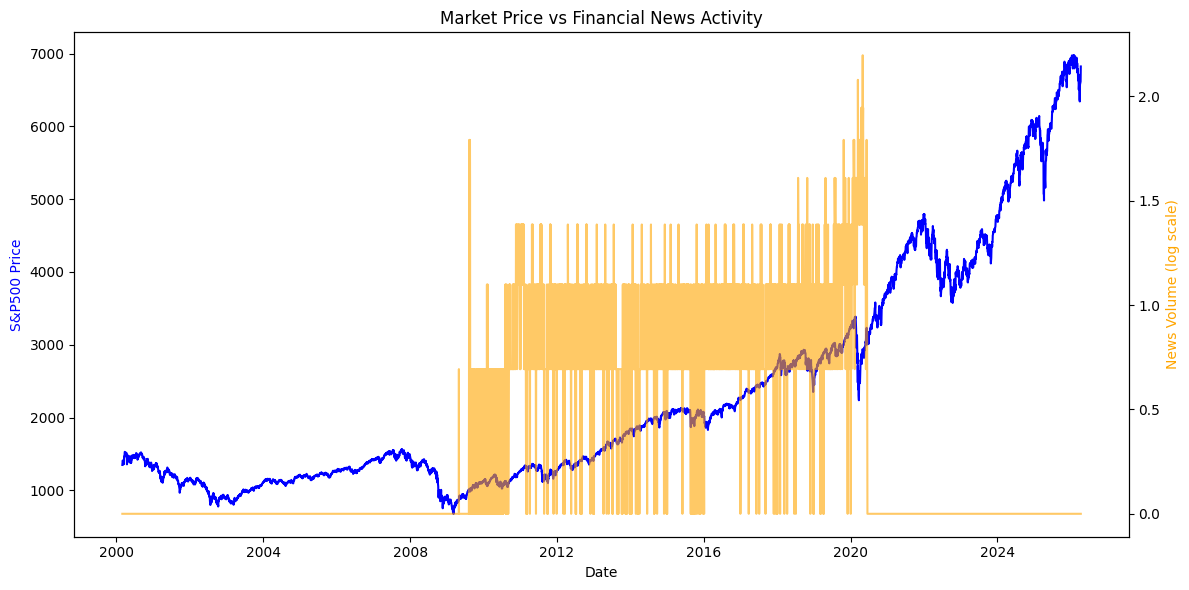

In [12]:
# ============================================================
# CELL — MARKET PRICE VS NEWS ACTIVITY
# ------------------------------------------------------------
# Visualize S&P500 price together with the volume of financial
# news to observe how information flow relates to market moves.
# ============================================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# ------------------------------------------------------------
# PLOT MARKET PRICE
# ------------------------------------------------------------

ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    label="S&P500 Price"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("S&P500 Price", color="blue")

# ------------------------------------------------------------
# SECOND AXIS FOR NEWS VOLUME
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["news_volume"],
    color="orange",
    alpha=0.6,
    label="News Volume"
)

ax2.set_ylabel("News Volume (log scale)", color="orange")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title("Market Price vs Financial News Activity")

fig.tight_layout()

plt.show()

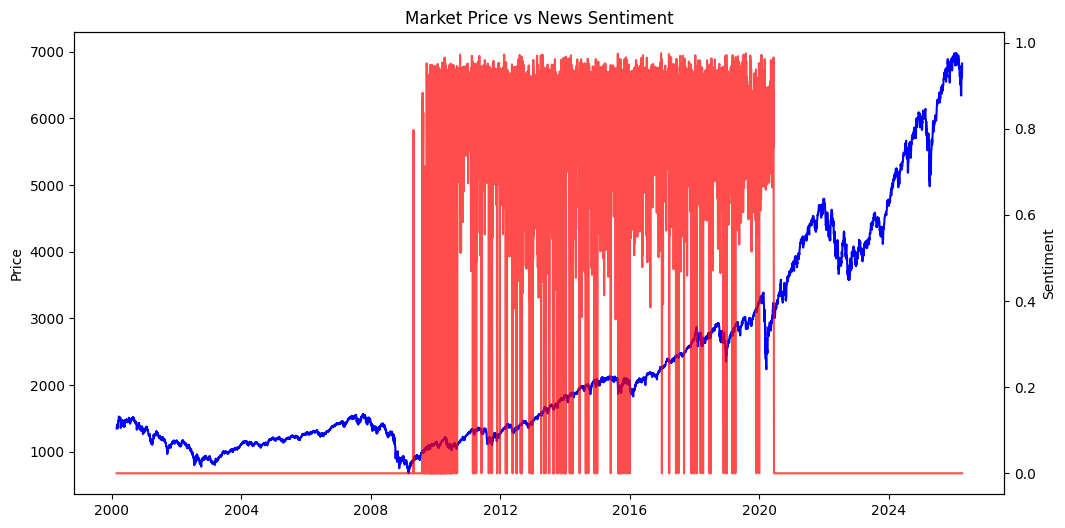

In [13]:
fig, ax1 = plt.subplots(figsize=(12,6))

# price
ax1.plot(df["Date"], df["Close"], color="blue", label="S&P500")

ax1.set_ylabel("Price")

# sentiment
ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["sentiment_mean"],
    color="red",
    alpha=0.7,
    label="Sentiment score"
)

ax2.set_ylabel("Sentiment")

plt.title("Market Price vs News Sentiment")

plt.show()

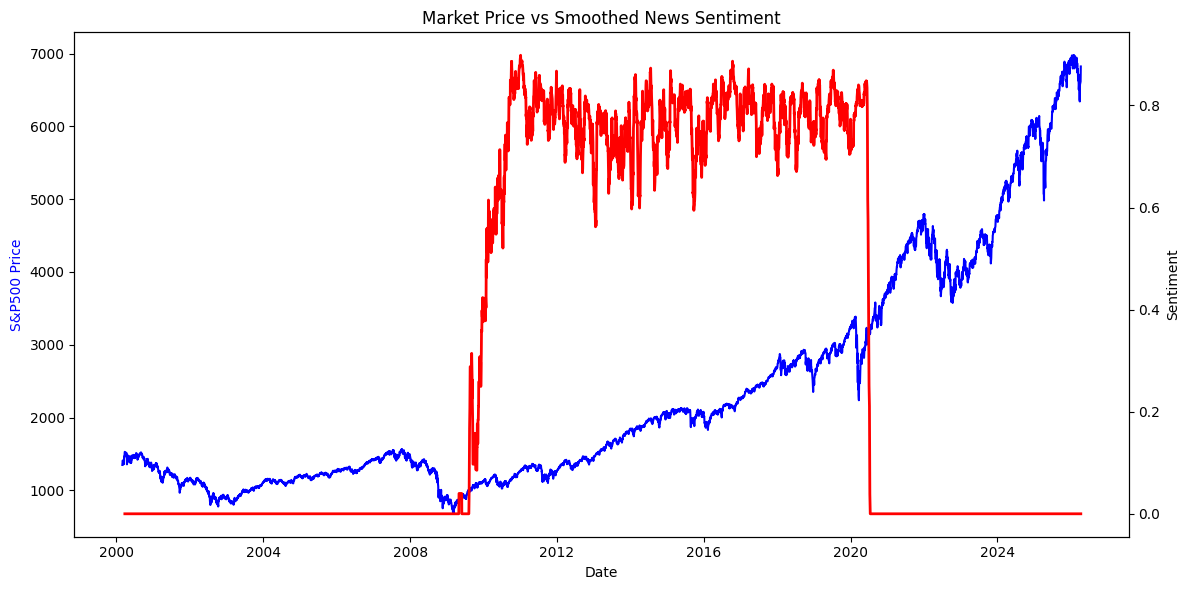

In [14]:
# ============================================================
# CELL — SMOOTH SENTIMENT SIGNAL
# ------------------------------------------------------------
# Apply rolling mean to sentiment to reduce daily noise
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SMOOTH SENTIMENT
# ------------------------------------------------------------

WINDOW = 20   # about 1 trading month

df["sentiment_smooth"] = df["sentiment_mean"].rolling(WINDOW).mean()

# ------------------------------------------------------------
# PLOT PRICE VS SMOOTH SENTIMENT
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12,6))

# Price
ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    label="S&P500 Price"
)

ax1.set_ylabel("S&P500 Price", color="blue")
ax1.set_xlabel("Date")

# Sentiment
ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["sentiment_smooth"],
    color="red",
    linewidth=2,
    label="Sentiment (20-day mean)"
)

ax2.set_ylabel("Sentiment")

# Title
plt.title("Market Price vs Smoothed News Sentiment")

fig.tight_layout()

plt.show()

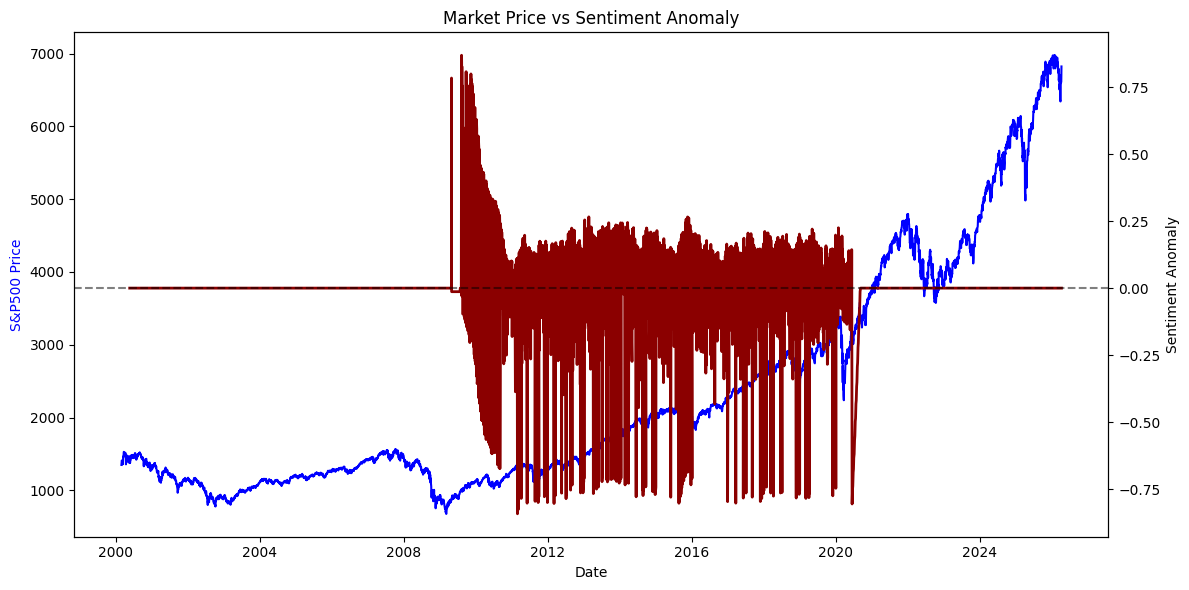

In [15]:
# ============================================================
# CELL — SENTIMENT ANOMALY
# ------------------------------------------------------------
# Compute deviations of sentiment from its long-term average
# to detect unusual optimism or pessimism in financial news
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# COMPUTE SENTIMENT ANOMALY
# ------------------------------------------------------------

WINDOW = 60   # about 3 trading months

df["sentiment_baseline"] = df["sentiment_mean"].rolling(WINDOW).mean()

df["sentiment_anomaly"] = df["sentiment_mean"] - df["sentiment_baseline"]


# ------------------------------------------------------------
# PLOT PRICE VS SENTIMENT ANOMALY
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(12,6))

# Price
ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    label="S&P500 Price"
)

ax1.set_ylabel("S&P500 Price", color="blue")
ax1.set_xlabel("Date")


# Sentiment anomaly
ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    df["sentiment_anomaly"],
    color="darkred",
    linewidth=2,
    label="Sentiment Anomaly"
)

ax2.axhline(0, color="black", linestyle="--", alpha=0.5)

ax2.set_ylabel("Sentiment Anomaly")

plt.title("Market Price vs Sentiment Anomaly")

fig.tight_layout()

plt.show()

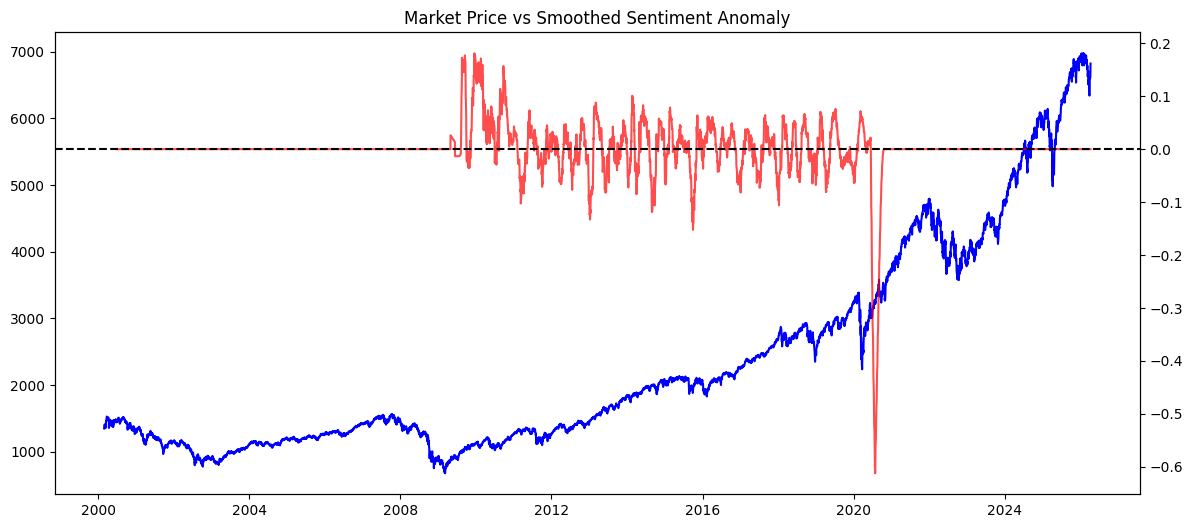

In [16]:
sent_roll = df["sentiment_anomaly"].rolling(30).mean()

plt.figure(figsize=(14,6))

plt.plot(df["Date"], df["Close"], color="blue", label="S&P500")

plt.twinx()

plt.plot(df["Date"], sent_roll, color="red", alpha=0.7,
         label="Sentiment anomaly (30d MA)")

plt.axhline(0, linestyle="--", color="black")

plt.title("Market Price vs Smoothed Sentiment Anomaly")

plt.show()

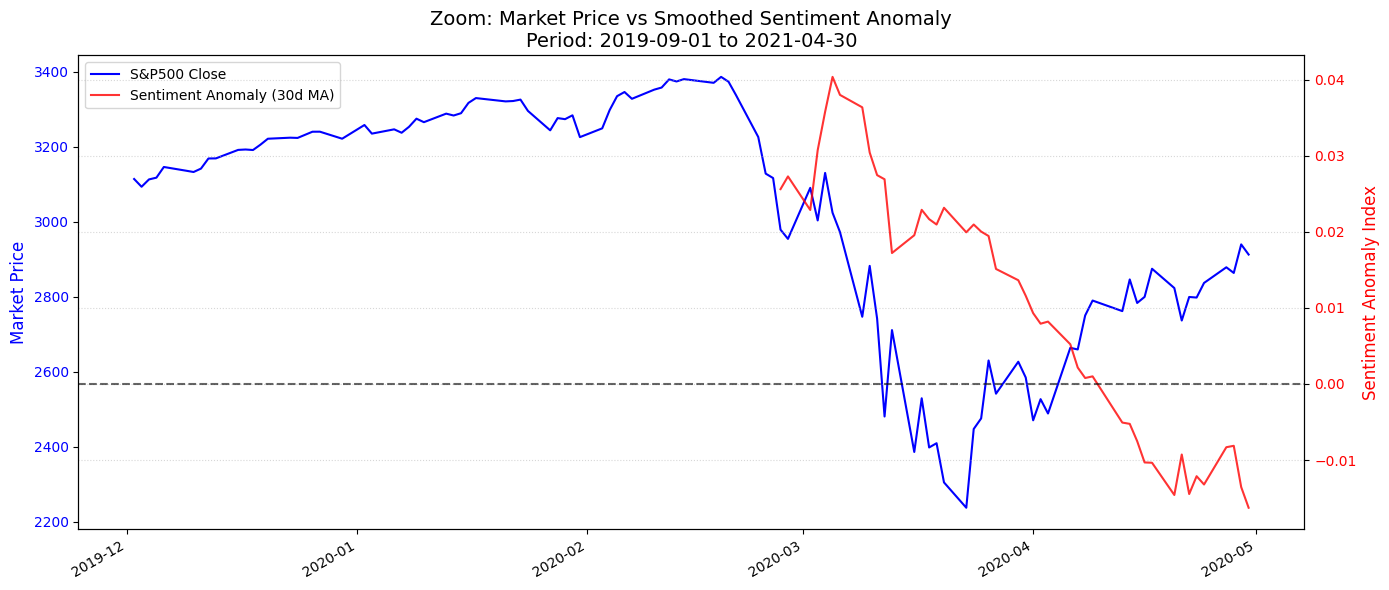

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurações Iniciais
WINDOW = 30  # Define a janela para o baseline (podes ajustar para 7 se o DF for muito curto)

# 2. Garantir formato de data
df["Date"] = pd.to_datetime(df["Date"])

# 3. Calcular a Anomalia de Sentimento (conforme a tua fórmula)
df["sentiment_baseline"] = df["sentiment_mean"].rolling(WINDOW).mean()
df["sentiment_anomaly"] = df["sentiment_mean"] - df["sentiment_baseline"]

# 4. Calcular a versão suavizada para o traço vermelho (ex: média móvel da anomalia)
# Nota: Usamos a anomalia que acabaste de calcular
sent_roll = df["sentiment_anomaly"].rolling(WINDOW).mean()

# 5. Definir o intervalo de datas para o zoom
start_date = pd.to_datetime("2019-09-01")
end_date = pd.to_datetime("2021-04-30")

# 6. Filtrar os dados para o plot
mask = (df["Date"] >= start_date) & (df["Date"] <= end_date)
df_zoom = df.loc[mask].copy()
sent_roll_zoom = sent_roll.loc[mask]

# 7. Criar a Visualização
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo Esquerdo: Preço
ax1.plot(df_zoom["Date"], df_zoom["Close"], color="blue", label="S&P500 Close", linewidth=1.5)
ax1.set_ylabel("Market Price", color="blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="blue")

# Eixo Direito: Anomalia Suavizada
ax2 = ax1.twinx()
ax2.plot(df_zoom["Date"], sent_roll_zoom, color="red", alpha=0.8, 
         label=f"Sentiment Anomaly ({WINDOW}d MA)", linewidth=1.5)
ax2.set_ylabel("Sentiment Anomaly Index", color="red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="red")

# Linha de referência no ZERO (onde a média atual iguala o baseline)
ax2.axhline(0, linestyle="--", color="black", alpha=0.6)

# Títulos e Legendas
plt.title(f"Zoom: Market Price vs Smoothed Sentiment Anomaly\nPeriod: {start_date.date()} to {end_date.date()}", fontsize=14)
fig.autofmt_xdate()
plt.grid(True, linestyle=':', alpha=0.5)

# Unir as legendas dos dois eixos num só quadro
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()

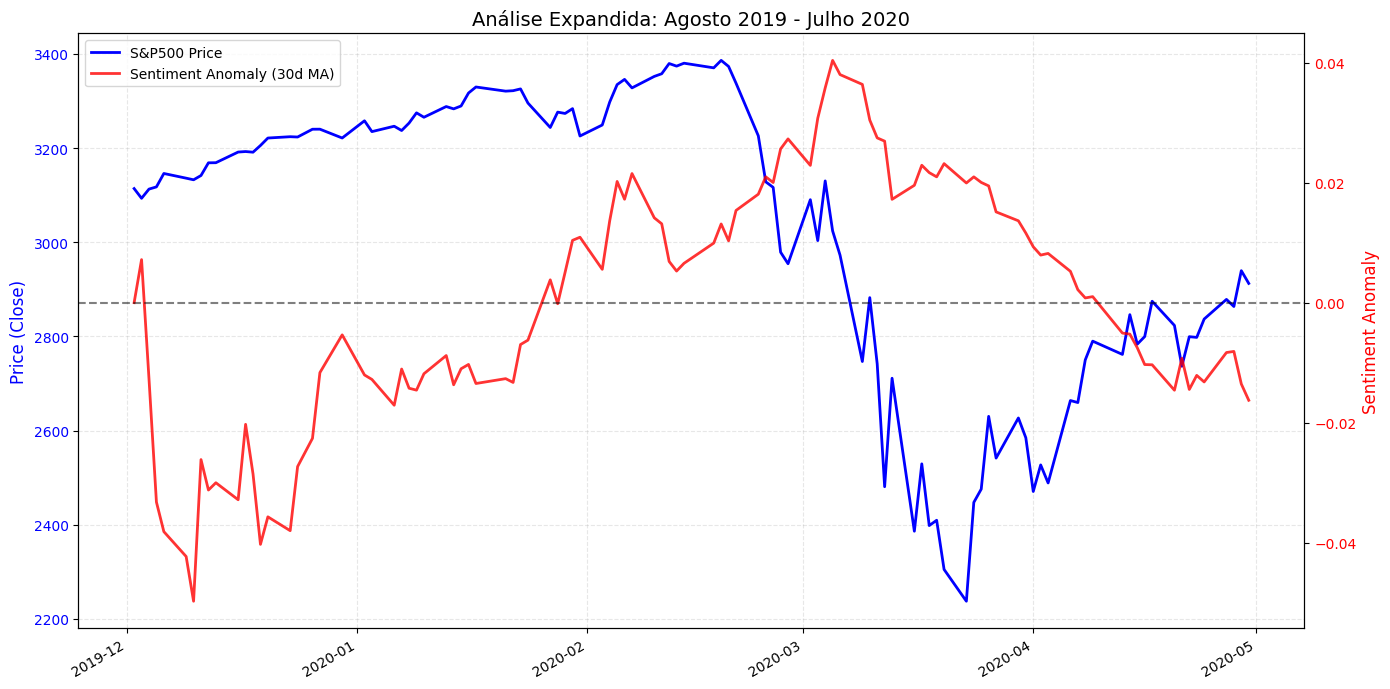

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurações
WINDOW = 30 
df["Date"] = pd.to_datetime(df["Date"])

# 2. Cálculos (Feitos no DF total para evitar o buraco de 30 dias no zoom)
# O min_periods=1 obriga o pandas a calcular a média mesmo com poucos dias iniciais
df["sentiment_baseline"] = df["sentiment_mean"].rolling(window=WINDOW, min_periods=1).mean()
df["sentiment_anomaly"] = df["sentiment_mean"] - df["sentiment_baseline"]
df["sent_roll"] = df["sentiment_anomaly"].rolling(window=WINDOW, min_periods=1).mean()

# 3. Definição do novo intervalo (Agosto 2019 até Julho 2020)
start_zoom = pd.to_datetime("2019-08-01")
end_zoom = pd.to_datetime("2020-07-31")

# 4. Filtro para o gráfico
mask = (df["Date"] >= start_zoom) & (df["Date"] <= end_zoom)
df_zoom = df.loc[mask].copy()

# 5. Visualização
fig, ax1 = plt.subplots(figsize=(14, 7))

# Preço (Azul)
ax1.plot(df_zoom["Date"], df_zoom["Close"], color="blue", label="S&P500 Price", linewidth=2)
ax1.set_ylabel("Price (Close)", color="blue", fontsize=12)
ax1.tick_params(axis='y', labelcolor="blue")

# Sentimento (Vermelho)
ax2 = ax1.twinx()
ax2.plot(df_zoom["Date"], df_zoom["sent_roll"], color="red", alpha=0.8, 
         label="Sentiment Anomaly (30d MA)", linewidth=2)
ax2.set_ylabel("Sentiment Anomaly", color="red", fontsize=12)
ax2.tick_params(axis='y', labelcolor="red")

# Estética
ax2.axhline(0, linestyle="--", color="black", alpha=0.5)
ax1.grid(True, which='both', linestyle='--', alpha=0.3)
plt.title("Análise Expandida: Agosto 2019 - Julho 2020", fontsize=14)
fig.autofmt_xdate()

# Legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper left")

plt.tight_layout()
plt.show()

In [55]:
%who

DATASETS_DIR	 DOWN_THRESHOLD	 EXPERIMENT_TYPE	 FEATURES_DIR	 FEATURE_COLUMNS	 MARKET_FEATURES_PATH	 MARKET_FEATURE_PATH	 MERGED_DATASET_PATH	 META_PATH	 
ML_DIR	 MODE	 NEWS_FEATURE_PATH	 N_EVENTS	 OUTPUT_PATH	 PROJECT_ROOT	 Path	 RAW_DIR	 SENTIMENT_EXPORT_PATH	 
SENTIMENT_FEATURES_PATH	 UP_THRESHOLD	 USE_NEWS	 WINDOW	 X	 after	 analysis_df	 available_market	 available_news	 
ax	 ax1	 ax2	 before	 class_counts	 class_pct	 columns_needed	 combined	 corr	 
corrs	 crash	 crash_dates	 cumulative	 d	 daily_sent	 daily_sentiment	 data	 data2	 
date	 dates	 days	 df	 df_period	 df_price	 df_sent	 df_zoom	 display	 
drop_prob	 end	 end_zoom	 event_dates	 events	 existing_cols	 existing_news_cols	 extreme_events	 extreme_neg	 
f	 fig	 final_rows	 grouped	 i	 initial_rows	 json	 lags	 market_df	 
market_features	 mask	 max_lag	 mean_path	 mean_sent	 metadata	 min_len	 missing_features	 negative	 
neutral	 news_cols	 news_df	 news_features	 np	 p	 paths	 pd	 plt	 
price	 returns	 rows	 sent	 sent_

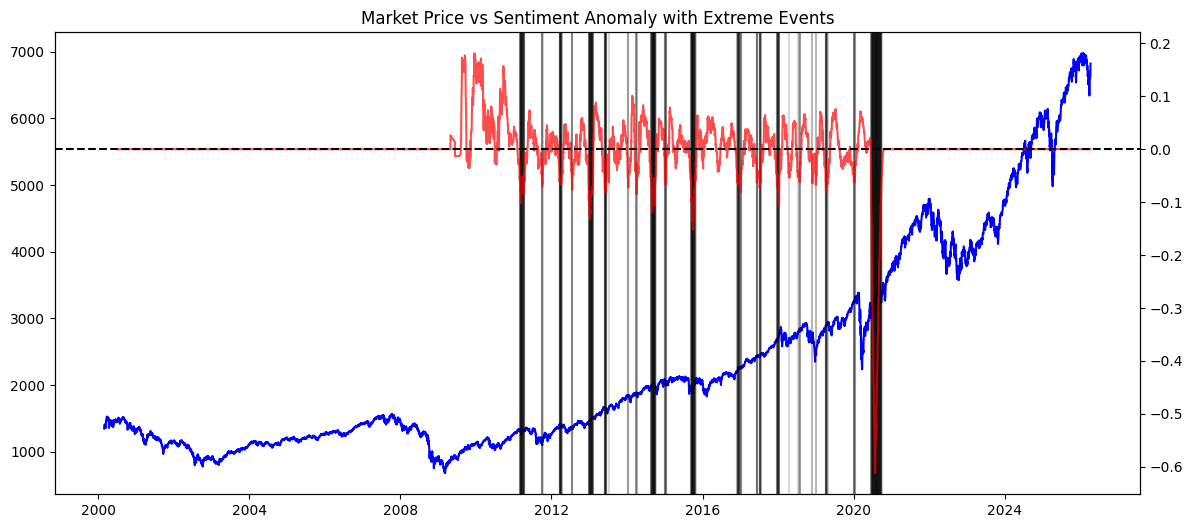

In [17]:
# ============================================================
# CELL — PRICE vs SENTIMENT WITH EXTREME NEGATIVE SENTIMENT
# ------------------------------------------------------------
# Overlay vertical lines when sentiment anomaly becomes
# extremely negative to inspect alignment with market moves
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# SMOOTH SENTIMENT
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# DEFINE EXTREME NEGATIVE SENTIMENT THRESHOLD
# (bottom 5%)
# ------------------------------------------------------------

threshold = np.percentile(sent_roll.dropna(), 5)

extreme_neg = sent_roll < threshold

# ------------------------------------------------------------
# PLOT PRICE
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(df["Date"], df["Close"],
         color="blue",
         label="S&P500")

# ------------------------------------------------------------
# ADD VERTICAL LINES FOR EXTREME SENTIMENT
# ------------------------------------------------------------

for date in df["Date"][extreme_neg]:
    ax1.axvline(date,
                color="black",
                alpha=0.15)

# ------------------------------------------------------------
# SENTIMENT AXIS
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(df["Date"],
         sent_roll,
         color="red",
         alpha=0.7,
         label="Sentiment anomaly (30d MA)")

ax2.axhline(0,
            linestyle="--",
            color="black")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title("Market Price vs Sentiment Anomaly with Extreme Events")

plt.show()

Extreme negative sentiment events: 13


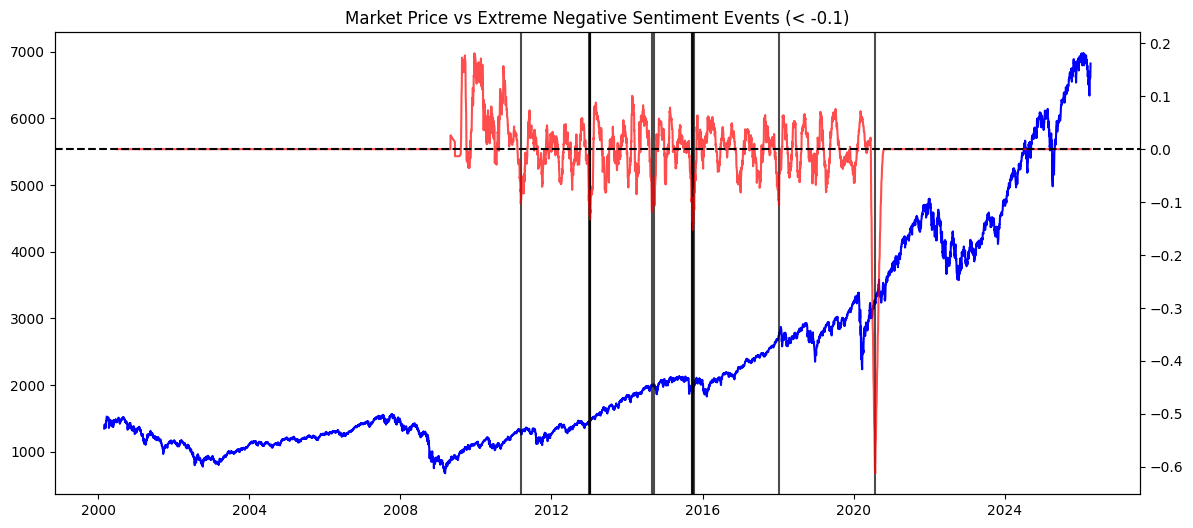

In [18]:
# ============================================================
# PRICE vs SENTIMENT WITH EXTREME NEGATIVE EVENTS (< -0.1)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# SMOOTH SENTIMENT
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# THRESHOLD
# ------------------------------------------------------------

threshold = -0.1

# ------------------------------------------------------------
# DETECT LOCAL MINIMA BELOW THRESHOLD
# ------------------------------------------------------------

extreme_events = (
    (sent_roll < threshold) &
    (sent_roll.shift(1) > sent_roll) &
    (sent_roll.shift(-1) > sent_roll)
)

event_dates = df.loc[extreme_events, "Date"]

print("Extreme negative sentiment events:", len(event_dates))

# ------------------------------------------------------------
# PLOT PRICE
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    label="S&P500"
)

# ------------------------------------------------------------
# VERTICAL EVENT LINES
# ------------------------------------------------------------

for d in event_dates:
    ax1.axvline(
        d,
        color="black",
        alpha=0.7,
        linewidth=1.5
    )

# ------------------------------------------------------------
# SENTIMENT AXIS
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    sent_roll,
    color="red",
    alpha=0.7,
    label="Sentiment anomaly (30d MA)"
)

ax2.axhline(0, linestyle="--", color="black")

plt.title("Market Price vs Extreme Negative Sentiment Events (< -0.1)")

plt.show()

Top crash events:
           Date  return_1d
5043 2020-03-16  -0.127652
5041 2020-03-12  -0.099945
5038 2020-03-09  -0.079010
2879 2011-08-08  -0.068958
5104 2020-06-11  -0.060753


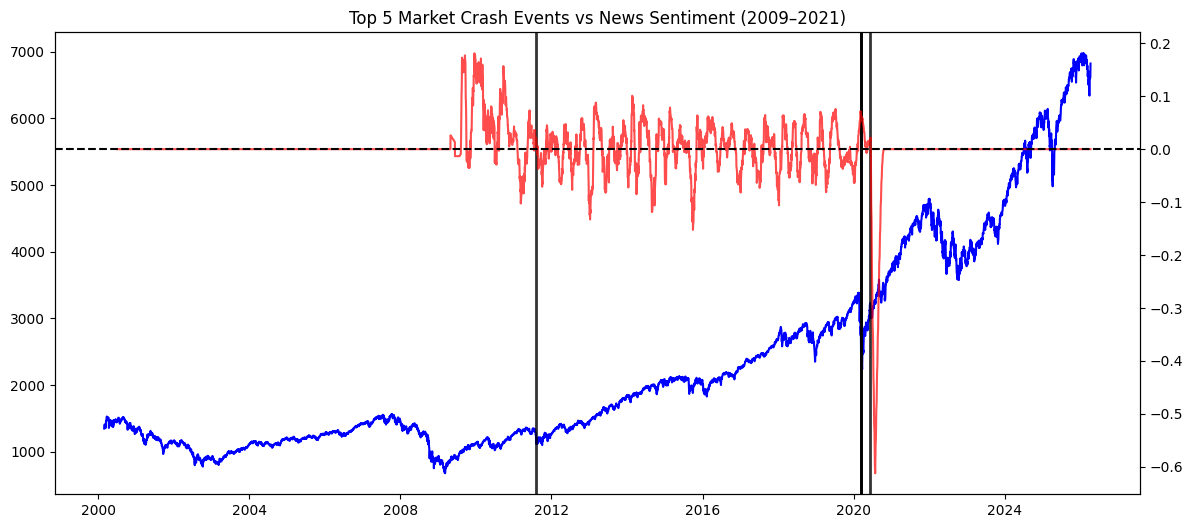

In [19]:
# ============================================================
# PRICE vs SENTIMENT WITH TOP 5 MARKET CRASHES
# ------------------------------------------------------------
# Mark the 5 largest daily drops in the S&P500 (2009–2021)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# COMPUTE DAILY RETURNS
# ------------------------------------------------------------

df["return_1d"] = np.log(df["Close"] / df["Close"].shift(1))

# ------------------------------------------------------------
# SELECT PERIOD OF INTEREST
# ------------------------------------------------------------

mask = (df["Date"] >= "2009-01-01") & (df["Date"] <= "2021-12-31")
df_period = df.loc[mask].copy()

# ------------------------------------------------------------
# FIND 5 LARGEST DROPS
# ------------------------------------------------------------

top_crashes = df_period.nsmallest(5, "return_1d")

print("Top crash events:")
print(top_crashes[["Date", "return_1d"]])

crash_dates = top_crashes["Date"]

# ------------------------------------------------------------
# SENTIMENT SMOOTHING
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# PLOT PRICE
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    label="S&P500"
)

# ------------------------------------------------------------
# VERTICAL LINES FOR TOP CRASHES
# ------------------------------------------------------------

for d in crash_dates:
    ax1.axvline(
        d,
        color="black",
        linewidth=2,
        alpha=0.8
    )

# ------------------------------------------------------------
# SENTIMENT AXIS
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df["Date"],
    sent_roll,
    color="red",
    alpha=0.7,
    label="Sentiment anomaly (30d MA)"
)

ax2.axhline(0, linestyle="--", color="black")

plt.title("Top 5 Market Crash Events vs News Sentiment (2009–2021)")

plt.show()

Top crash events:
           Date  return_1d
5043 2020-03-16  -0.127652
5041 2020-03-12  -0.099945
5038 2020-03-09  -0.079010
2879 2011-08-08  -0.068958
5104 2020-06-11  -0.060753
2236 2009-01-20  -0.054262
5045 2020-03-18  -0.053222
2251 2009-02-10  -0.050369
5040 2020-03-11  -0.050103
2877 2011-08-04  -0.049002


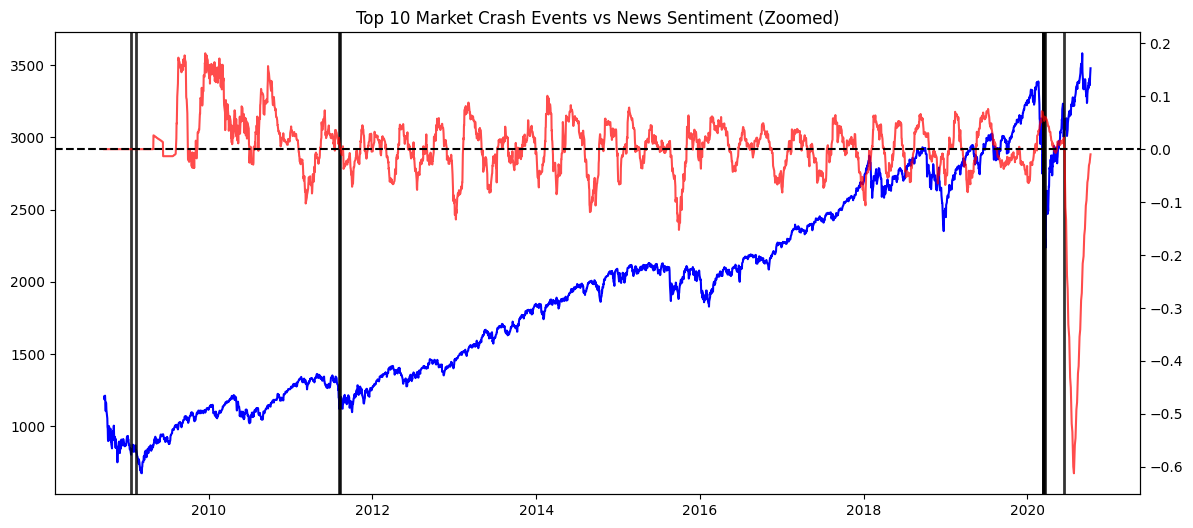

In [20]:
# ============================================================
# TOP 10 MARKET CRASH EVENTS WITH ZOOMED VIEW
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# COMPUTE DAILY RETURNS
# ------------------------------------------------------------

df["return_1d"] = np.log(df["Close"] / df["Close"].shift(1))

# ------------------------------------------------------------
# FILTER PERIOD
# ------------------------------------------------------------

mask = (df["Date"] >= "2009-01-01") & (df["Date"] <= "2021-12-31")
df_period = df.loc[mask].copy()

# ------------------------------------------------------------
# TOP 10 CRASH EVENTS
# ------------------------------------------------------------

top_crashes = df_period.nsmallest(10, "return_1d")

crash_dates = top_crashes["Date"]

print("Top crash events:")
print(top_crashes[["Date", "return_1d"]])

# ------------------------------------------------------------
# DEFINE ZOOM WINDOW
# ------------------------------------------------------------

start_zoom = crash_dates.min() - pd.Timedelta(days=120)
end_zoom = crash_dates.max() + pd.Timedelta(days=120)

df_zoom = df[(df["Date"] >= start_zoom) & (df["Date"] <= end_zoom)]

# ------------------------------------------------------------
# SENTIMENT SMOOTH
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

ax1.plot(
    df_zoom["Date"],
    df_zoom["Close"],
    color="blue",
    label="S&P500"
)

# ------------------------------------------------------------
# VERTICAL LINES
# ------------------------------------------------------------

for d in crash_dates:
    ax1.axvline(
        d,
        color="black",
        linewidth=2,
        alpha=0.8
    )

# ------------------------------------------------------------
# SENTIMENT
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df_zoom["Date"],
    sent_roll.loc[df_zoom.index],
    color="red",
    alpha=0.7,
)

ax2.axhline(0, linestyle="--", color="black")

plt.title("Top 10 Market Crash Events vs News Sentiment (Zoomed)")

plt.show()

Number of sentiment shock events: 638


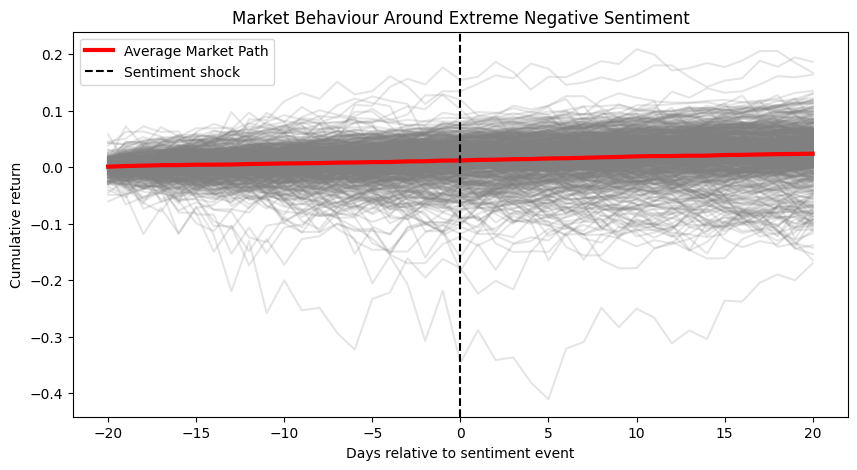

In [21]:
# ============================================================
# EVENT STUDY — MARKET BEHAVIOUR AROUND NEGATIVE SENTIMENT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

threshold = -0.1
window = 20

# ------------------------------------------------------------
# COMPUTE RETURNS
# ------------------------------------------------------------

df["return_1d"] = np.log(df["Close"] / df["Close"].shift(1))

# ------------------------------------------------------------
# DETECT SENTIMENT EVENTS
# ------------------------------------------------------------

events = df[df["sentiment_anomaly"] < threshold].index

print("Number of sentiment shock events:", len(events))

# ------------------------------------------------------------
# COLLECT RETURN WINDOWS
# ------------------------------------------------------------

paths = []

for i in events:
    
    if i-window < 0 or i+window >= len(df):
        continue
    
    window_returns = df["return_1d"].iloc[i-window:i+window+1].values
    
    cumulative = np.cumsum(window_returns)
    
    paths.append(cumulative)

paths = np.array(paths)

# ------------------------------------------------------------
# AVERAGE PATH
# ------------------------------------------------------------

mean_path = paths.mean(axis=0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

x = np.arange(-window, window+1)

plt.figure(figsize=(10,5))

# individual events (light)
for p in paths:
    plt.plot(x, p, color="gray", alpha=0.2)

# mean behaviour
plt.plot(x, mean_path, color="red", linewidth=3, label="Average Market Path")

plt.axvline(0, linestyle="--", color="black", label="Sentiment shock")

plt.xlabel("Days relative to sentiment event")
plt.ylabel("Cumulative return")

plt.title("Market Behaviour Around Extreme Negative Sentiment")

plt.legend()

plt.show()

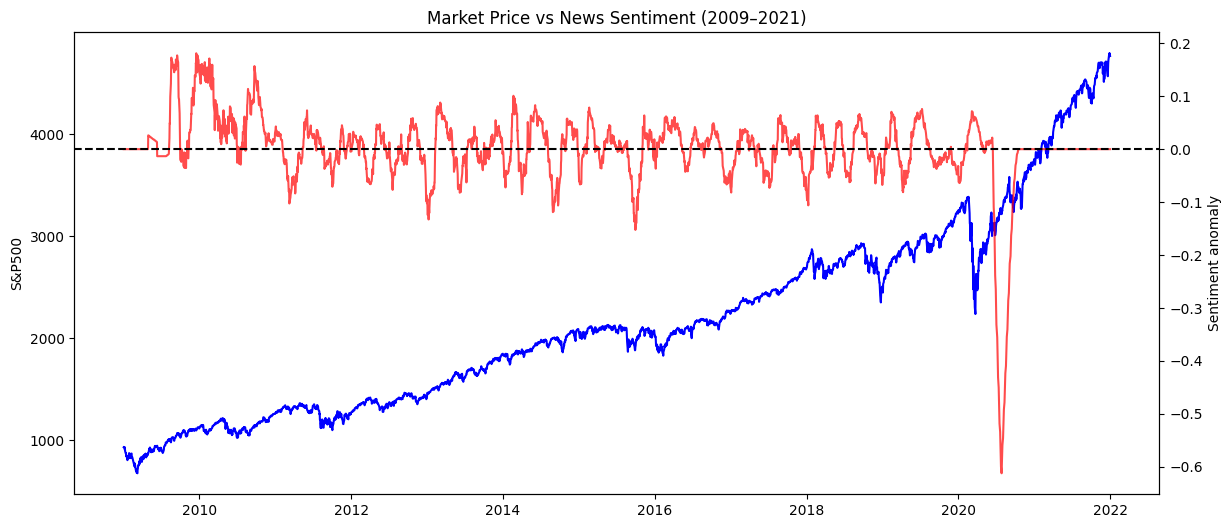

In [22]:
# ============================================================
# MARKET PRICE vs SENTIMENT (NO EVENT LINES)
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# SENTIMENT SMOOTH
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# ZOOM WINDOW
# ------------------------------------------------------------

start_zoom = "2009-01-01"
end_zoom = "2021-12-31"

df_zoom = df[(df["Date"] >= start_zoom) & (df["Date"] <= end_zoom)]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

# S&P500
ax1.plot(
    df_zoom["Date"],
    df_zoom["Close"],
    color="blue",
    label="S&P500"
)

ax1.set_ylabel("S&P500")

# ------------------------------------------------------------
# SENTIMENT AXIS
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df_zoom["Date"],
    sent_roll.loc[df_zoom.index],
    color="red",
    alpha=0.7,
    label="Sentiment anomaly (30d MA)"
)

ax2.axhline(0, linestyle="--", color="black")

ax2.set_ylabel("Sentiment anomaly")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title("Market Price vs News Sentiment (2009–2021)")

plt.show()

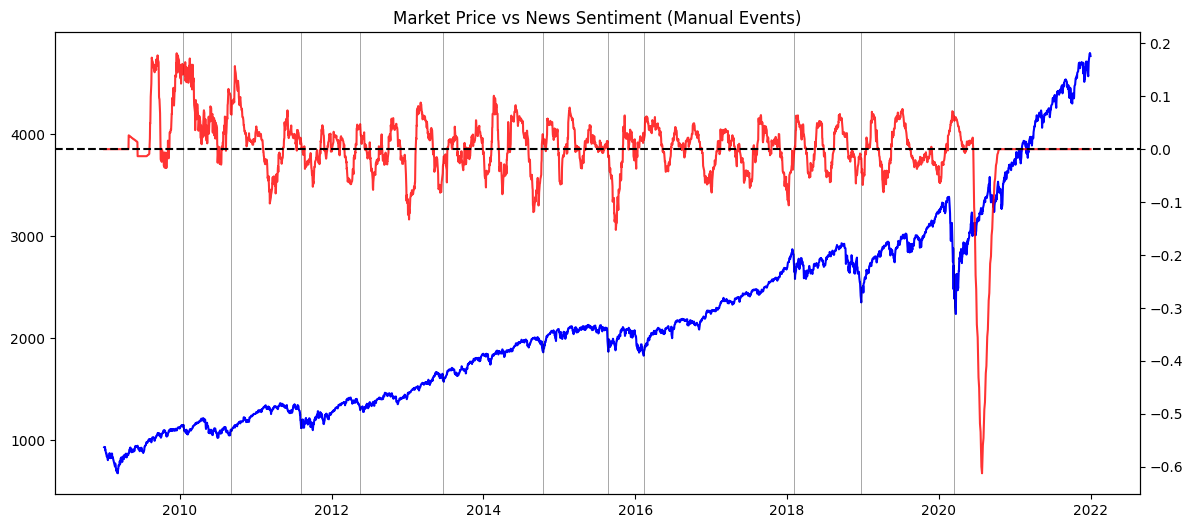

In [23]:
# ============================================================
# PLOT WITH MANUALLY SELECTED SENTIMENT EVENTS (THIN LINES)
# ============================================================

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,6))

# ------------------------------------------------------------
# PRICE
# ------------------------------------------------------------

ax1.plot(
    df_zoom["Date"],
    df_zoom["Close"],
    color="blue",
    label="S&P500"
)

# ------------------------------------------------------------
# MANUAL EVENT DATES  (as mesmas que desenhaste)
# ------------------------------------------------------------

event_dates = [
    # colocar aqui as datas que usaste
    # exemplo:
    "2010-01-15",
    "2010-09-02",
    "2011-08-05",
    "2012-05-18",
    "2013-06-20",
    "2014-10-15",
    "2015-08-24",
    "2016-02-11",
    "2018-02-05",
    "2018-12-24",
    "2020-03-16"
]

event_dates = pd.to_datetime(event_dates)

# ------------------------------------------------------------
# THIN VERTICAL LINES
# ------------------------------------------------------------

for d in event_dates:
    ax1.axvline(
        d,
        color="black",
        linewidth=0.6,   # linha fina
        alpha=0.4        # ligeira transparência
    )

# ------------------------------------------------------------
# SENTIMENT
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df_zoom["Date"],
    sent_roll.loc[df_zoom.index],
    color="red",
    alpha=0.8
)

ax2.axhline(0, linestyle="--", color="black")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title("Market Price vs News Sentiment (Manual Events)")
plt.show()

Worst sentiment events:
           Date  sentiment_anomaly
2767 2011-02-28          -0.841906
2772 2011-03-07          -0.826526
2775 2011-03-10          -0.815928
5106 2020-06-15          -0.805259


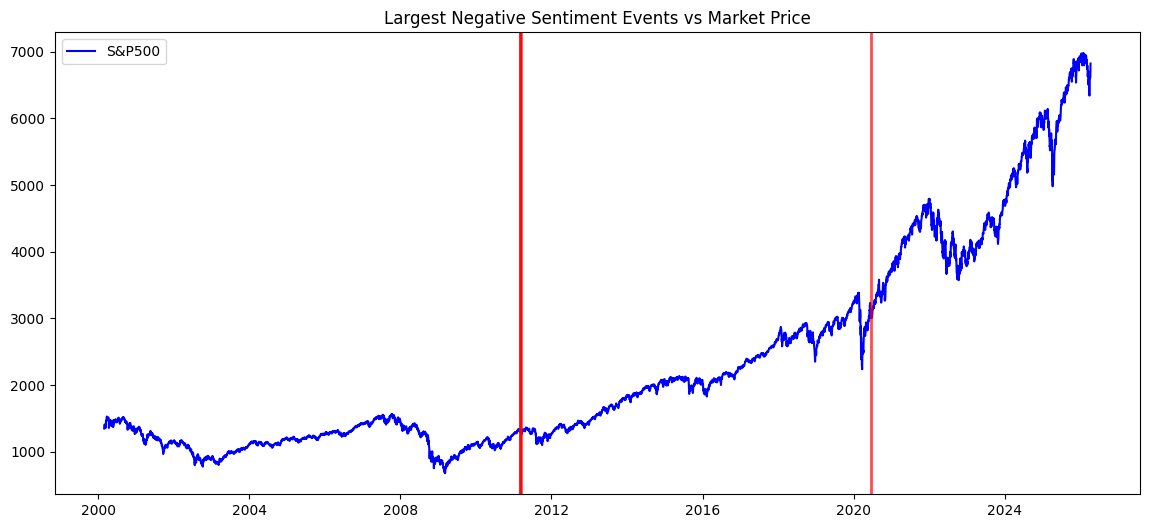

In [24]:
# ============================================================
# TOP SENTIMENT CRASH EVENTS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# NUMBER OF EVENTS TO SHOW
# ------------------------------------------------------------

N_EVENTS = 4

# ------------------------------------------------------------
# FIND MOST NEGATIVE SENTIMENT DAYS
# ------------------------------------------------------------

worst_events = df.nsmallest(N_EVENTS, "sentiment_anomaly")

print("Worst sentiment events:")
print(worst_events[["Date","sentiment_anomaly"]])

# ------------------------------------------------------------
# PLOT MARKET
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(df["Date"], df["Close"], color="blue", label="S&P500")

# ------------------------------------------------------------
# PLOT EVENT LINES
# ------------------------------------------------------------

for d in worst_events["Date"]:
    
    ax.axvline(
        d,
        color="red",
        linewidth=2,
        alpha=0.7
    )

plt.title("Largest Negative Sentiment Events vs Market Price")

plt.legend()

plt.show()

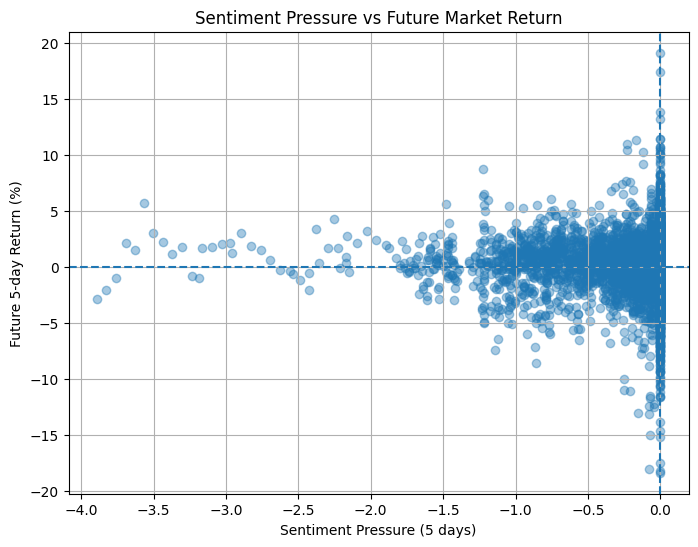

In [25]:
# ============================================================
# SENTIMENT PRESSURE vs FUTURE 5D RETURN
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------

window = 5

# ------------------------------------------------------------
# SENTIMENT PRESSURE
# ------------------------------------------------------------

df["sentiment_pressure"] = (
    df["sentiment_anomaly"]
    .apply(lambda x: min(x, 0))
    .rolling(window)
    .sum()
)

# ------------------------------------------------------------
# FUTURE 5-DAY RETURN
# ------------------------------------------------------------

df["future_return_5d"] = (
    df["Close"].shift(-5) / df["Close"] - 1
)

# ------------------------------------------------------------
# REMOVE NaNs
# ------------------------------------------------------------

data = df[["sentiment_pressure", "future_return_5d"]].dropna()

# ------------------------------------------------------------
# SCATTER PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    data["sentiment_pressure"],
    data["future_return_5d"]*100,
    alpha=0.4
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Sentiment Pressure (5 days)")
plt.ylabel("Future 5-day Return (%)")

plt.title("Sentiment Pressure vs Future Market Return")

plt.grid(True)

plt.show()

group
Mild Negative            0.186308
Negative                 0.329918
No Negative Sentiment    0.081081
Slight Negative          0.142826
Very Negative            0.349397
Name: future_return_5d, dtype: float64


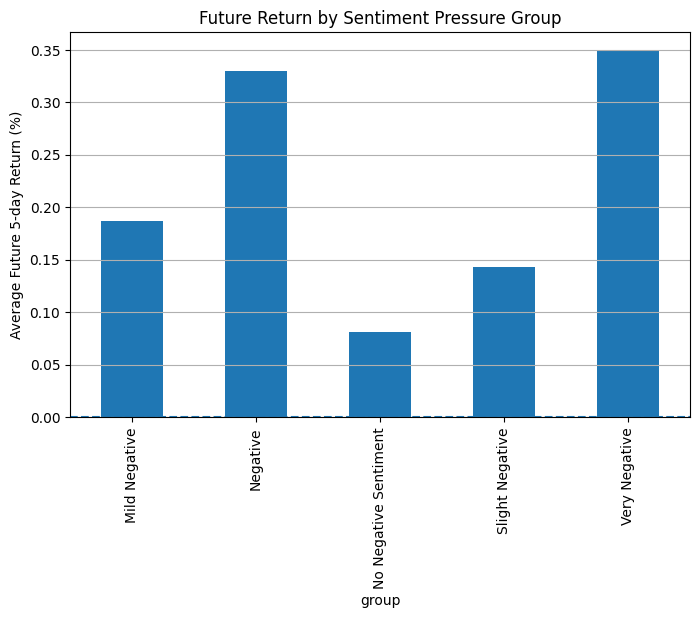

In [26]:
# ============================================================
# FUTURE RETURN BY SENTIMENT PRESSURE GROUP
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

data = df[["sentiment_pressure","future_return_5d"]].dropna().copy()

# separar pressão negativa
negative = data[data["sentiment_pressure"] < 0]
neutral = data[data["sentiment_pressure"] == 0]

# quintis apenas nos negativos
negative["group"] = pd.qcut(
    negative["sentiment_pressure"],
    4,
    labels=["Very Negative","Negative","Mild Negative","Slight Negative"]
)

neutral["group"] = "No Negative Sentiment"

data2 = pd.concat([negative,neutral])

# calcular média
grouped = data2.groupby("group")["future_return_5d"].mean()*100

print(grouped)

# plot
plt.figure(figsize=(8,5))
grouped.plot(kind="bar")

plt.axhline(0, linestyle="--")
plt.ylabel("Average Future 5-day Return (%)")
plt.title("Future Return by Sentiment Pressure Group")

plt.grid(axis="y")
plt.show()

group
Mild Negative            41.213064
Negative                 39.285714
No Negative Sentiment    44.866242
Slight Negative          39.813375
Very Negative            36.744186
Name: market_drop, dtype: float64


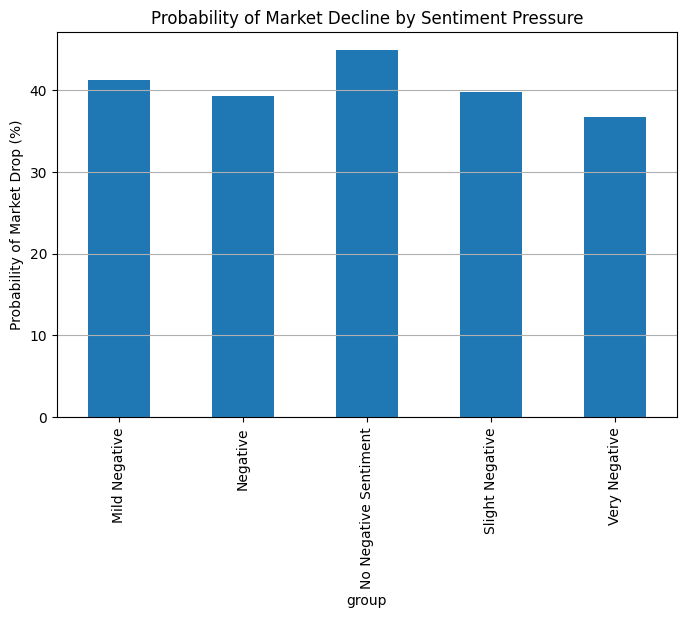

In [27]:
# ============================================================
# PROBABILITY OF MARKET DROP BY SENTIMENT PRESSURE GROUP
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

data = df[["sentiment_pressure","future_return_5d"]].dropna().copy()

# ------------------------------------------------------------
# CREATE DROP INDICATOR
# ------------------------------------------------------------

data["market_drop"] = (data["future_return_5d"] < 0).astype(int)

# ------------------------------------------------------------
# SPLIT NEGATIVE / ZERO PRESSURE
# ------------------------------------------------------------

negative = data[data["sentiment_pressure"] < 0]
neutral = data[data["sentiment_pressure"] == 0]

negative["group"] = pd.qcut(
    negative["sentiment_pressure"],
    4,
    labels=["Very Negative","Negative","Mild Negative","Slight Negative"]
)

neutral["group"] = "No Negative Sentiment"

data2 = pd.concat([negative,neutral])

# ------------------------------------------------------------
# COMPUTE PROBABILITY OF DROP
# ------------------------------------------------------------

drop_prob = data2.groupby("group")["market_drop"].mean()*100

print(drop_prob)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

drop_prob.plot(kind="bar")

plt.ylabel("Probability of Market Drop (%)")

plt.title("Probability of Market Decline by Sentiment Pressure")

plt.grid(axis="y")

plt.show()

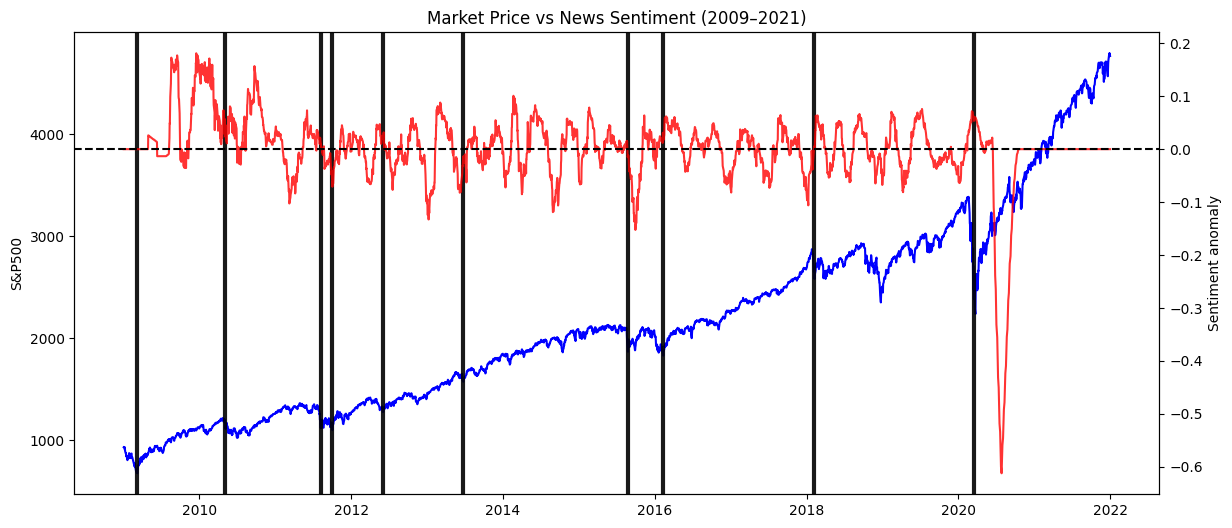

In [28]:
# ============================================================
# MARKET PRICE vs SENTIMENT WITH MANUAL CRASH LINES
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# MANUAL CRASH DATES (adjust if needed)
# ------------------------------------------------------------

crash_dates = [
    "2009-03-09",
    "2010-05-06",
    "2011-08-08",
    "2011-10-03",
    "2012-06-04",
    "2013-06-24",
    "2015-08-24",
    "2016-02-11",
    "2018-02-05",
    "2020-03-16"
]

crash_dates = pd.to_datetime(crash_dates)

# ------------------------------------------------------------
# SENTIMENT SMOOTHING
# ------------------------------------------------------------

sent_roll = df["sentiment_anomaly"].rolling(30).mean()

# ------------------------------------------------------------
# SELECT PERIOD
# ------------------------------------------------------------

mask = (df["Date"] >= "2009-01-01") & (df["Date"] <= "2021-12-31")
df_zoom = df.loc[mask]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14,6))

# Price
ax1.plot(
    df_zoom["Date"],
    df_zoom["Close"],
    color="blue",
    label="S&P500"
)

ax1.set_ylabel("S&P500")

# ------------------------------------------------------------
# VERTICAL CRASH LINES
# ------------------------------------------------------------

for d in crash_dates:
    ax1.axvline(
        d,
        color="black",
        linewidth=3,
        alpha=0.9
    )

# ------------------------------------------------------------
# SENTIMENT AXIS
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(
    df_zoom["Date"],
    sent_roll.loc[df_zoom.index],
    color="red",
    alpha=0.8,
)

ax2.axhline(0, linestyle="--", color="black")

ax2.set_ylabel("Sentiment anomaly")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------

plt.title("Market Price vs News Sentiment (2009–2021)")

plt.show()

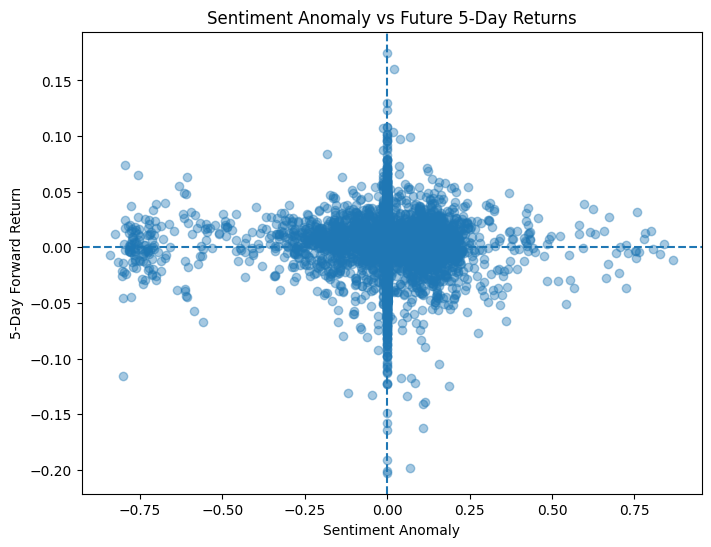

In [29]:
# ============================================================
# CELL — SENTIMENT VS FUTURE RETURNS
# ------------------------------------------------------------
# Check if sentiment anomaly has predictive power for
# 5-day forward returns (same horizon as the model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# COMPUTE DAILY RETURNS
# ------------------------------------------------------------

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

# ------------------------------------------------------------
# COMPUTE 5-DAY FORWARD RETURN
# ------------------------------------------------------------

df["future_return_5d"] = (
    df["log_return"]
    .shift(-1)
    .rolling(5)
    .sum()
)

# ------------------------------------------------------------
# REMOVE NaN VALUES
# ------------------------------------------------------------

analysis_df = df.dropna(subset=["sentiment_anomaly", "future_return_5d"])

# ------------------------------------------------------------
# SCATTER PLOT
# ------------------------------------------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["sentiment_anomaly"],
    analysis_df["future_return_5d"],
    alpha=0.4
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("Sentiment Anomaly")
plt.ylabel("5-Day Forward Return")

plt.title("Sentiment Anomaly vs Future 5-Day Returns")

plt.show()

In [30]:
# ============================================================
# CELL — SHOW ALL COLUMNS
# ============================================================

import pandas as pd

pd.set_option("display.max_columns", None)

print(df.columns)

Index(['Date', 'ticker', 'Open', 'High', 'Low', 'Close', 'Volume',
       'simple_return', 'log_return', 'sma_10', 'sma_20', 'ema_10', 'ema_20',
       'sma_ratio_10', 'sma_ratio_20', 'ema_ratio_10', 'ema_ratio_20', 'mom_5',
       'mom_10', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'volatility_10',
       'volatility_20', 'high_low_range', 'drawdown_10', 'drawdown_20',
       'max_drawdown_20', 'drawdown_change', 'drawdown_abs',
       'drawdown_persistence', 'volatility_20_sq', 'ret_5', 'ret_10',
       'log_volume', 'volume_change', 'volume_ma_10', 'volume_ratio_10',
       'sentiment_mean', 'sentiment_std', 'news_volume', 'sentiment_momentum',
       'news_available', 'future_return_5d', 'target', 'sentiment_smooth',
       'sentiment_baseline', 'sentiment_anomaly', 'return_1d',
       'sentiment_pressure'],
      dtype='str')


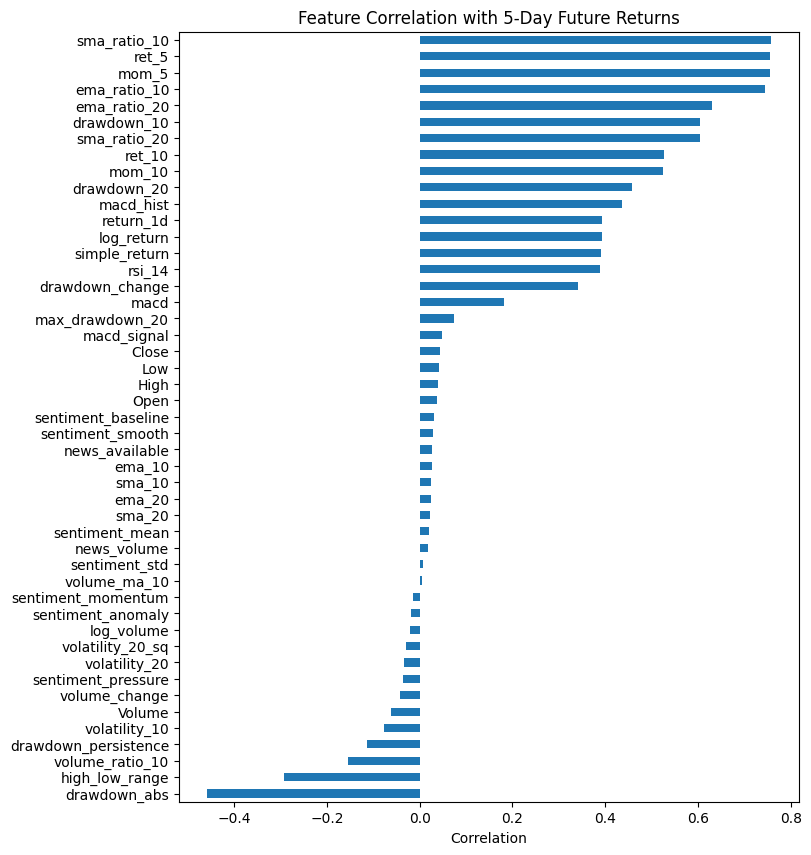

In [31]:
# ============================================================
# CORRELATION WITH TARGET (EXCLUDING TARGET ITSELF)
# ============================================================

import matplotlib.pyplot as plt

target = "future_return_5d"

corr = (
    df.corr(numeric_only=True)[target]
    .drop(target)        # remove self-correlation
    .sort_values()
)

plt.figure(figsize=(8,10))

corr.plot(kind="barh")

plt.title("Feature Correlation with 5-Day Future Returns")

plt.xlabel("Correlation")

plt.show()

In [32]:
%who

DATASETS_DIR	 DOWN_THRESHOLD	 EXPERIMENT_TYPE	 FEATURES_DIR	 FEATURE_COLUMNS	 MARKET_FEATURES_PATH	 MARKET_FEATURE_PATH	 MERGED_DATASET_PATH	 META_PATH	 
ML_DIR	 MODE	 NEWS_FEATURE_PATH	 N_EVENTS	 OUTPUT_PATH	 PROJECT_ROOT	 Path	 RAW_DIR	 SENTIMENT_FEATURES_PATH	 
UP_THRESHOLD	 USE_NEWS	 WINDOW	 X	 analysis_df	 available_market	 available_news	 ax	 ax1	 
ax2	 class_counts	 class_pct	 columns_needed	 corr	 crash_dates	 cumulative	 d	 daily_sentiment	 
data	 data2	 date	 dates	 df	 df_period	 df_zoom	 display	 drop_prob	 
end_zoom	 event_dates	 events	 existing_cols	 existing_news_cols	 extreme_events	 extreme_neg	 f	 fig	 
final_rows	 grouped	 i	 initial_rows	 json	 market_df	 market_features	 mask	 mean_path	 
metadata	 missing_features	 negative	 neutral	 news_cols	 news_df	 news_features	 np	 p	 
paths	 pd	 plt	 rows	 sent_roll	 sentiment_cols	 start_zoom	 target	 threshold	 
tickers	 top_crashes	 warnings	 window	 window_returns	 worst_events	 x	 y	 


In [35]:
# ============================================================
# EXPORT DAILY SENTIMENT SERIES FOR NOTEBOOK 8
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# SELECT SENTIMENT COLUMN
# ------------------------------------------------------------

sentiment_export = daily_sentiment[["Date", "sentiment_mean"]].copy()

sentiment_export = sentiment_export.rename(
    columns={"sentiment_mean": "sentiment"}
)

sentiment_export["Date"] = pd.to_datetime(sentiment_export["Date"])

sentiment_export = sentiment_export.sort_values("Date")

# ------------------------------------------------------------
# SAVE FILE
# ------------------------------------------------------------

SENTIMENT_EXPORT_PATH = DATASETS_DIR / "daily_sentiment_series.csv"

sentiment_export.to_csv(SENTIMENT_EXPORT_PATH, index=False)

print("Sentiment exported to:")
print(SENTIMENT_EXPORT_PATH)

print("\nPreview:")
print(sentiment_export.head())

Sentiment exported to:
c:\Users\anton\0______MASTER_IN_DATA_SCIENCE\1_SEMESTRE\RESEARCH_METHODOLOGIES\RESEARCH_METHODOLOGIES_2\ML_Stocks_LSTM\datasets\datasets\daily_sentiment_series.csv

Preview:
        Date  sentiment
0 2009-04-29   0.797031
1 2009-08-07   0.883442
2 2009-08-10   0.868877
3 2009-08-12   0.870928
4 2009-08-13   0.719205


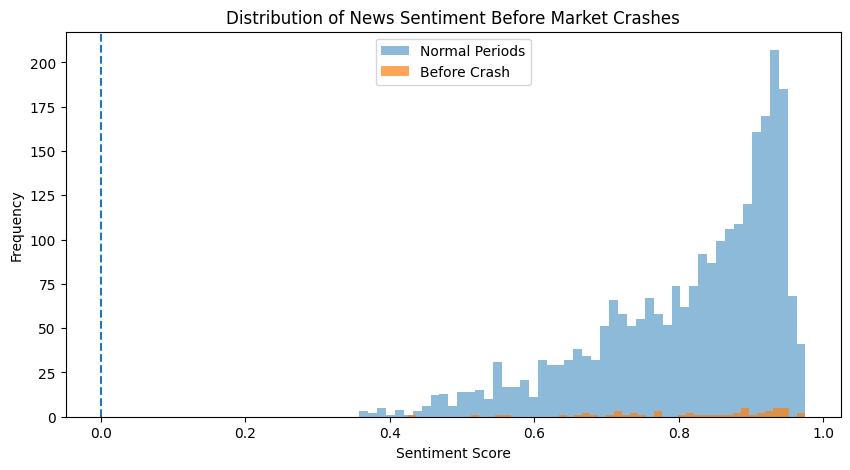

In [36]:
# ============================================================
# SENTIMENT DISTRIBUTION BEFORE CRASH EVENTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

df_sent = daily_sentiment.copy()
df_sent["Date"] = pd.to_datetime(df_sent["Date"])

crash_dates = pd.to_datetime([
    "2009-03-09",
    "2010-05-06",
    "2011-08-08",
    "2011-10-03",
    "2012-06-04",
    "2013-06-24",
    "2015-08-24",
    "2016-02-11",
    "2018-02-05",
    "2020-03-16"
])

# ------------------------------------------------------------
# COLLECT SENTIMENT BEFORE CRASHES
# ------------------------------------------------------------

sent_before = []
sent_normal = []

for crash in crash_dates:

    window = df_sent[
        (df_sent["Date"] >= crash - pd.Timedelta(days=10)) &
        (df_sent["Date"] < crash)
    ]

    sent_before.extend(window["sentiment_mean"].values)

# sentiment outside crash windows
mask = pd.Series(True, index=df_sent.index)

for crash in crash_dates:
    mask &= ~(
        (df_sent["Date"] >= crash - pd.Timedelta(days=10)) &
        (df_sent["Date"] < crash)
    )

sent_normal = df_sent.loc[mask, "sentiment_mean"].values

# ------------------------------------------------------------
# PLOT DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.hist(sent_normal, bins=50, alpha=0.5, label="Normal Periods")
plt.hist(sent_before, bins=50, alpha=0.7, label="Before Crash")

plt.axvline(0, linestyle="--")

plt.title("Distribution of News Sentiment Before Market Crashes")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.legend()

plt.show()

Crash events used: 9


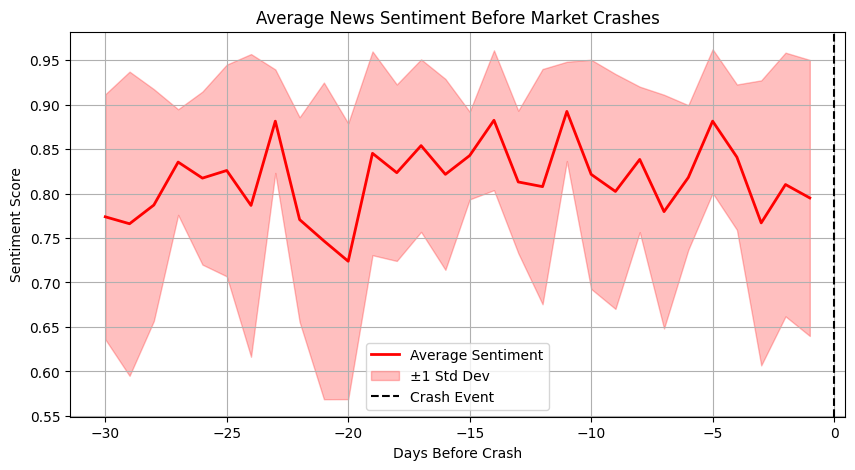

In [40]:
# ============================================================
# AVERAGE SENTIMENT TRAJECTORY BEFORE MARKET CRASHES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE DATA
# ------------------------------------------------------------

df_sent = daily_sentiment.copy()
df_sent["Date"] = pd.to_datetime(df_sent["Date"])
df_sent = df_sent.sort_values("Date")

crash_dates = pd.to_datetime([
    "2009-03-09",
    "2010-05-06",
    "2011-08-08",
    "2011-10-03",
    "2012-06-04",
    "2013-06-24",
    "2015-08-24",
    "2016-02-11",
    "2018-02-05",
    "2020-03-16"
])

window = 30

# ------------------------------------------------------------
# COLLECT LAST AVAILABLE OBSERVATIONS BEFORE EACH CRASH
# ------------------------------------------------------------

sent_matrix = []

for crash in crash_dates:
    window_data = df_sent[df_sent["Date"] < crash].tail(window)

    if len(window_data) > 5:
        values = pd.to_numeric(
            window_data["sentiment_mean"],
            errors="coerce"
        ).dropna().values

        if len(values) > 5:
            sent_matrix.append(values)

print("Crash events used:", len(sent_matrix))

# ------------------------------------------------------------
# ALIGN LENGTHS
# ------------------------------------------------------------

min_len = min(len(x) for x in sent_matrix)

sent_matrix = np.vstack([
    np.asarray(x[-min_len:], dtype=float) for x in sent_matrix
])

# ------------------------------------------------------------
# COMPUTE AVERAGE TRAJECTORY
# ------------------------------------------------------------

mean_sent = sent_matrix.mean(axis=0)
std_sent = sent_matrix.std(axis=0)

days = np.arange(-min_len, 0)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    days,
    mean_sent,
    color="red",
    linewidth=2,
    label="Average Sentiment"
)

plt.fill_between(
    days,
    mean_sent - std_sent,
    mean_sent + std_sent,
    color="red",
    alpha=0.25,
    label="±1 Std Dev"
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    label="Crash Event"
)

plt.title("Average News Sentiment Before Market Crashes")
plt.xlabel("Days Before Crash")
plt.ylabel("Sentiment Score")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# ============================================================
# CROSS-CORRELATION: SENTIMENT vs MARKET RETURNS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE MARKET RETURNS
# ------------------------------------------------------------

df_price = sp500.copy()
df_price["Date"] = pd.to_datetime(df_price["Date"])

df_price["return"] = np.log(df_price["Close"]).diff()

# ------------------------------------------------------------
# PREPARE SENTIMENT
# ------------------------------------------------------------

df_sent = daily_sentiment.copy()
df_sent["Date"] = pd.to_datetime(df_sent["Date"])

# ------------------------------------------------------------
# MERGE DATASETS
# ------------------------------------------------------------

df = pd.merge(
    df_price[["Date","return"]],
    df_sent[["Date","sentiment_mean"]],
    on="Date",
    how="inner"
)

df = df.dropna()

returns = df["return"]
sentiment = df["sentiment_mean"]

# ------------------------------------------------------------
# COMPUTE CROSS CORRELATION
# ------------------------------------------------------------

max_lag = 20

lags = range(-max_lag, max_lag+1)

corrs = [
    sentiment.shift(lag).corr(returns)
    for lag in lags
]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(lags, corrs, marker="o")

plt.axvline(0, linestyle="--", color="black")

plt.title("Cross-Correlation Between News Sentiment and Market Returns")

plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")

plt.grid(True)

plt.show()

NameError: name 'sp500' is not defined

In [42]:
%whos

Variable                  Type             Data/Info
----------------------------------------------------
DATASETS_DIR              WindowsPath      c:\Users\anton\0______MAS<...>ks_LSTM\datasets\datasets
DOWN_THRESHOLD            float            -0.015
EXPERIMENT_TYPE           str              hybrid
FEATURES_DIR              WindowsPath      c:\Users\anton\0______MAS<...>ks_LSTM\datasets\features
FEATURE_COLUMNS           list             n=20
MARKET_FEATURES_PATH      WindowsPath      c:\Users\anton\0______MAS<...>tures\market_features.csv
MARKET_FEATURE_PATH       WindowsPath      c:\Users\anton\0______MAS<...>tures\market_features.csv
MERGED_DATASET_PATH       WindowsPath      c:\Users\anton\0______MAS<...>ket_sentiment_dataset.csv
META_PATH                 WindowsPath      c:\Users\anton\0______MAS<...>sets\hybrid_metadata.json
ML_DIR                    WindowsPath      c:\Users\anton\0______MAS<...>L_Stocks_LSTM\datasets\ml
MODE                      str              HYBRID
NEW

In [43]:
%who

DATASETS_DIR	 DOWN_THRESHOLD	 EXPERIMENT_TYPE	 FEATURES_DIR	 FEATURE_COLUMNS	 MARKET_FEATURES_PATH	 MARKET_FEATURE_PATH	 MERGED_DATASET_PATH	 META_PATH	 
ML_DIR	 MODE	 NEWS_FEATURE_PATH	 N_EVENTS	 OUTPUT_PATH	 PROJECT_ROOT	 Path	 RAW_DIR	 SENTIMENT_EXPORT_PATH	 
SENTIMENT_FEATURES_PATH	 UP_THRESHOLD	 USE_NEWS	 WINDOW	 X	 analysis_df	 available_market	 available_news	 ax	 
ax1	 ax2	 class_counts	 class_pct	 columns_needed	 corr	 crash	 crash_dates	 cumulative	 
d	 daily_sentiment	 data	 data2	 date	 dates	 days	 df	 df_period	 
df_sent	 df_zoom	 display	 drop_prob	 end_zoom	 event_dates	 events	 existing_cols	 existing_news_cols	 
extreme_events	 extreme_neg	 f	 fig	 final_rows	 grouped	 i	 initial_rows	 json	 
market_df	 market_features	 mask	 mean_path	 mean_sent	 metadata	 min_len	 missing_features	 negative	 
neutral	 news_cols	 news_df	 news_features	 np	 p	 paths	 pd	 plt	 
rows	 sent_before	 sent_matrix	 sent_normal	 sent_roll	 sentiment_cols	 sentiment_export	 start_zoom	 std_se

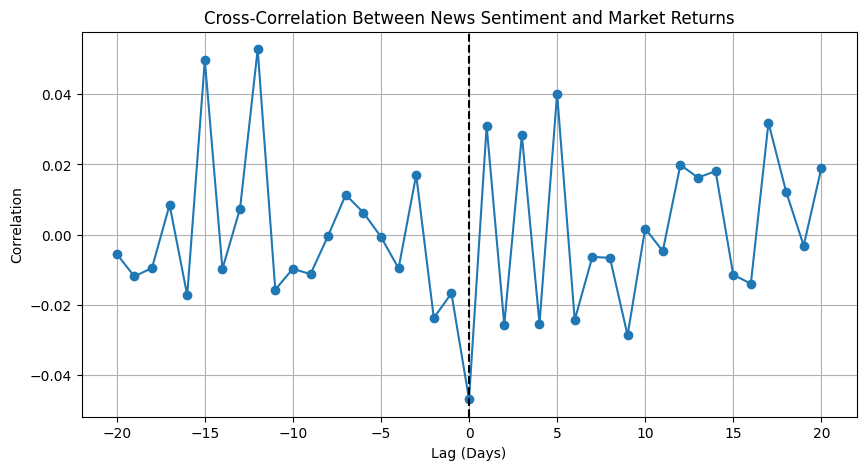

In [44]:
# ============================================================
# CROSS-CORRELATION: SENTIMENT vs MARKET RETURNS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE MARKET DATA
# ------------------------------------------------------------

df_price = market_df.copy()

df_price["Date"] = pd.to_datetime(df_price["Date"])

# log returns
df_price["return"] = np.log(df_price["Close"]).diff()

# ------------------------------------------------------------
# PREPARE SENTIMENT
# ------------------------------------------------------------

df_sent = daily_sentiment.copy()
df_sent["Date"] = pd.to_datetime(df_sent["Date"])

# ------------------------------------------------------------
# MERGE DATASETS
# ------------------------------------------------------------

df = pd.merge(
    df_price[["Date","return"]],
    df_sent[["Date","sentiment_mean"]],
    on="Date",
    how="inner"
)

df = df.dropna()

returns = df["return"]
sentiment = df["sentiment_mean"]

# ------------------------------------------------------------
# CROSS CORRELATION
# ------------------------------------------------------------

max_lag = 20
lags = range(-max_lag, max_lag+1)

corrs = [
    sentiment.shift(lag).corr(returns)
    for lag in lags
]

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(lags, corrs, marker="o")

plt.axvline(0, linestyle="--", color="black")

plt.title("Cross-Correlation Between News Sentiment and Market Returns")

plt.xlabel("Lag (Days)")
plt.ylabel("Correlation")

plt.grid(True)

plt.show()

Events used: 10


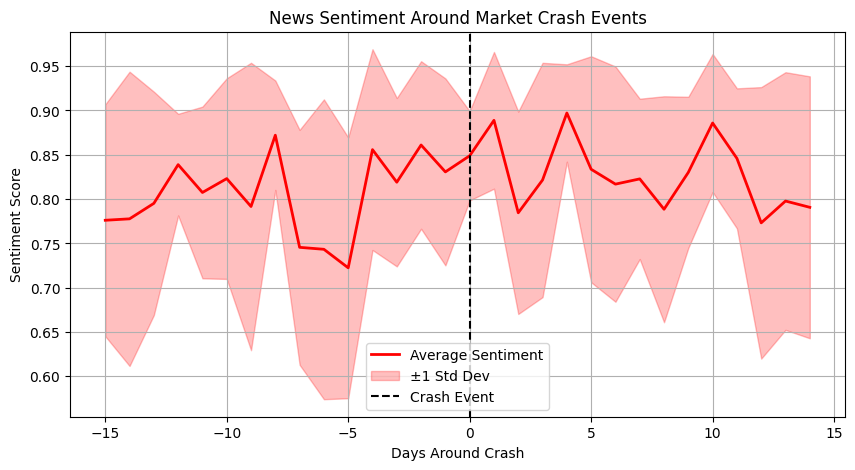

In [45]:
# ============================================================
# EVENT STUDY: NEWS SENTIMENT AROUND MARKET CRASHES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PREPARE SENTIMENT DATA
# ------------------------------------------------------------

df_sent = daily_sentiment.copy()
df_sent["Date"] = pd.to_datetime(df_sent["Date"])
df_sent = df_sent.sort_values("Date")

# ------------------------------------------------------------
# DEFINE CRASH EVENTS
# ------------------------------------------------------------

crash_dates = pd.to_datetime([
    "2009-03-09",
    "2010-05-06",
    "2011-08-08",
    "2011-10-03",
    "2012-06-04",
    "2013-06-24",
    "2015-08-24",
    "2016-02-11",
    "2018-02-05",
    "2020-03-16"
])

window = 30

sent_matrix = []

# ------------------------------------------------------------
# COLLECT WINDOWS AROUND CRASHES
# ------------------------------------------------------------

for crash in crash_dates:

    before = df_sent[df_sent["Date"] < crash].tail(window)
    after  = df_sent[df_sent["Date"] >= crash].head(window)

    combined = pd.concat([before, after])

    if len(combined) >= 10:

        values = pd.to_numeric(
            combined["sentiment_mean"],
            errors="coerce"
        ).dropna().values

        sent_matrix.append(values)

print("Events used:", len(sent_matrix))

# ------------------------------------------------------------
# ALIGN LENGTHS
# ------------------------------------------------------------

min_len = min(len(x) for x in sent_matrix)

sent_matrix = np.vstack([
    np.asarray(x[:min_len], dtype=float)
    for x in sent_matrix
])

# ------------------------------------------------------------
# COMPUTE AVERAGE TRAJECTORY
# ------------------------------------------------------------

mean_sent = sent_matrix.mean(axis=0)
std_sent = sent_matrix.std(axis=0)

days = np.arange(-min_len//2, min_len//2)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(days, mean_sent, color="red", linewidth=2, label="Average Sentiment")

plt.fill_between(
    days,
    mean_sent - std_sent,
    mean_sent + std_sent,
    color="red",
    alpha=0.25,
    label="±1 Std Dev"
)

plt.axvline(0, color="black", linestyle="--", label="Crash Event")

plt.title("News Sentiment Around Market Crash Events")

plt.xlabel("Days Around Crash")
plt.ylabel("Sentiment Score")

plt.legend()
plt.grid(True)

plt.show()

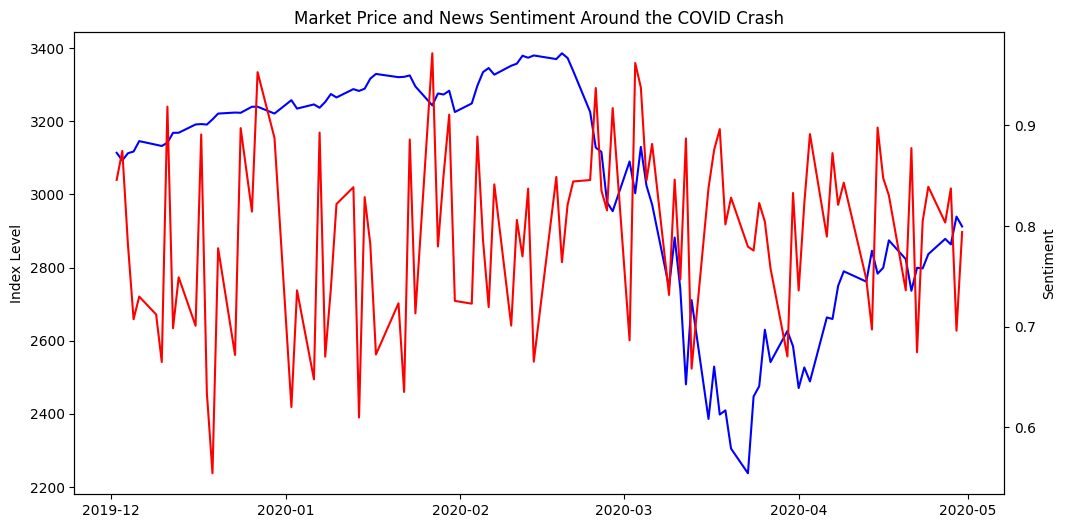

In [46]:
# ============================================================
# COVID CRASH CASE STUDY
# ============================================================

start = "2019-12-01"
end   = "2020-04-30"

price = market_df.copy()
price["Date"] = pd.to_datetime(price["Date"])

sent = daily_sentiment.copy()
sent["Date"] = pd.to_datetime(sent["Date"])

price = price[(price["Date"] >= start) & (price["Date"] <= end)]
sent  = sent[(sent["Date"] >= start) & (sent["Date"] <= end)]

df = pd.merge(
    price[["Date","Close"]],
    sent[["Date","sentiment_mean"]],
    on="Date",
    how="inner"
)

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(df["Date"], df["Close"], color="blue", label="S&P500")
ax1.set_ylabel("Index Level")

ax2 = ax1.twinx()

ax2.plot(df["Date"], df["sentiment_mean"], color="red", label="Sentiment")
ax2.set_ylabel("Sentiment")

plt.title("Market Price and News Sentiment Around the COVID Crash")

plt.show()

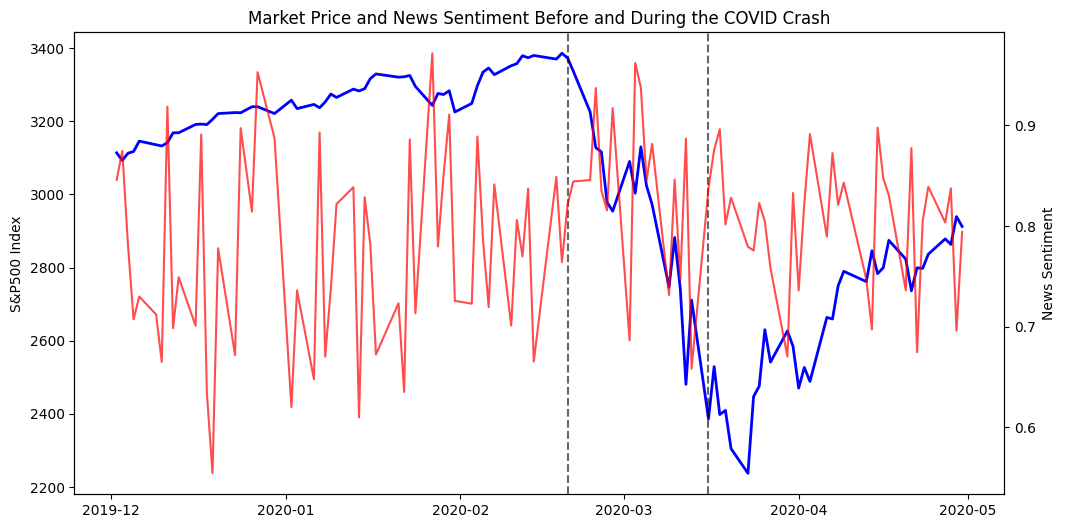

In [47]:
# ============================================================
# ZOOM: PRE-COVID AND COVID CRASH PERIOD
# ============================================================

start_zoom = "2019-09-01"
end_zoom   = "2020-04-30"

df_zoom = df[(df["Date"] >= start_zoom) & (df["Date"] <= end_zoom)]

fig, ax1 = plt.subplots(figsize=(12,6))

# ------------------------------------------------------------
# PRICE
# ------------------------------------------------------------

ax1.plot(df_zoom["Date"], df_zoom["Close"], color="blue", linewidth=2)
ax1.set_ylabel("S&P500 Index")

# ------------------------------------------------------------
# SENTIMENT
# ------------------------------------------------------------

ax2 = ax1.twinx()

ax2.plot(df_zoom["Date"], df_zoom["sentiment_mean"], color="red", alpha=0.7)
ax2.set_ylabel("News Sentiment")

# ------------------------------------------------------------
# IMPORTANT DATES
# ------------------------------------------------------------

ax1.axvline(pd.to_datetime("2020-02-20"), color="black", linestyle="--", alpha=0.6)
ax1.axvline(pd.to_datetime("2020-03-16"), color="black", linestyle="--", alpha=0.6)

plt.title("Market Price and News Sentiment Before and During the COVID Crash")

plt.show()

In [48]:
%who

DATASETS_DIR	 DOWN_THRESHOLD	 EXPERIMENT_TYPE	 FEATURES_DIR	 FEATURE_COLUMNS	 MARKET_FEATURES_PATH	 MARKET_FEATURE_PATH	 MERGED_DATASET_PATH	 META_PATH	 
ML_DIR	 MODE	 NEWS_FEATURE_PATH	 N_EVENTS	 OUTPUT_PATH	 PROJECT_ROOT	 Path	 RAW_DIR	 SENTIMENT_EXPORT_PATH	 
SENTIMENT_FEATURES_PATH	 UP_THRESHOLD	 USE_NEWS	 WINDOW	 X	 after	 analysis_df	 available_market	 available_news	 
ax	 ax1	 ax2	 before	 class_counts	 class_pct	 columns_needed	 combined	 corr	 
corrs	 crash	 crash_dates	 cumulative	 d	 daily_sentiment	 data	 data2	 date	 
dates	 days	 df	 df_period	 df_price	 df_sent	 df_zoom	 display	 drop_prob	 
end	 end_zoom	 event_dates	 events	 existing_cols	 existing_news_cols	 extreme_events	 extreme_neg	 f	 
fig	 final_rows	 grouped	 i	 initial_rows	 json	 lags	 market_df	 market_features	 
mask	 max_lag	 mean_path	 mean_sent	 metadata	 min_len	 missing_features	 negative	 neutral	 
news_cols	 news_df	 news_features	 np	 p	 paths	 pd	 plt	 price	 
returns	 rows	 sent	 sent_before	 sent

In [49]:
daily_sentiment

,Date,sentiment_mean,sentiment_std,news_volume,sentiment_momentum
0,2009-04-29,0.797031,NaN,0.693147,NaN
1,2009-08-07,0.883442,0.024994,1.098612,0.086412
2,2009-08-10,0.868877,0.119075,1.791759,-0.014565
3,2009-08-12,0.870928,0.042132,1.098612,0.002051
4,2009-08-13,0.719205,0.141693,1.609438,-0.151723
...,...,...,...,...,...
2593,2020-06-05,0.875134,0.131384,1.791759,0.076111
2594,2020-06-08,0.849927,0.154163,1.386294,-0.025207
2595,2020-06-09,0.756926,0.298146,1.098612,-0.093001
2596,2020-06-10,0.965465,0.008468,1.386294,0.208539


In [50]:
news_df

,title,date,stock,sentiment_label,sentiment_score,sentiment_value
0,Going Against the Herd,2009-04-29,A,neutral,0.797031,0
1,Denison Announces NI 43-101 Resource Estimates...,2009-08-07,NI,neutral,0.901116,0
2,Yorbeau Continues Drilling With Two Rigs,2009-08-07,D,neutral,0.865769,0
3,Jilin Jien and Goldbrook Formally Commence All...,2009-08-10,A,neutral,0.834757,0
4,Ahead of the Bell: China Armco Metals - August...,2009-08-10,FCX,neutral,0.948325,0
...,...,...,...,...,...,...
3999,"Coronavirus Squeezes Boeing Hard, Deliveries S...",2020-06-10,UAL,negative,0.970453,-1
4000,Shares of several energy companies are trading...,2020-06-10,EOG,negative,0.970254,-1
4001,Shares of several technology companies are tra...,2020-06-10,AMD,positive,0.955688,1
4002,"Benzinga's Top Upgrades, Downgrades For June 1...",2020-06-11,SJM,negative,0.569242,-1


In [51]:
df_sent = news_df.copy()

df_sent["date"] = pd.to_datetime(df_sent["date"])
df_sent = df_sent.sort_values("date")

In [52]:
start = "2019-09-01"
end   = "2020-04-30"

df_zoom = df_sent[
    (df_sent["date"] >= start) &
    (df_sent["date"] <= end)
]

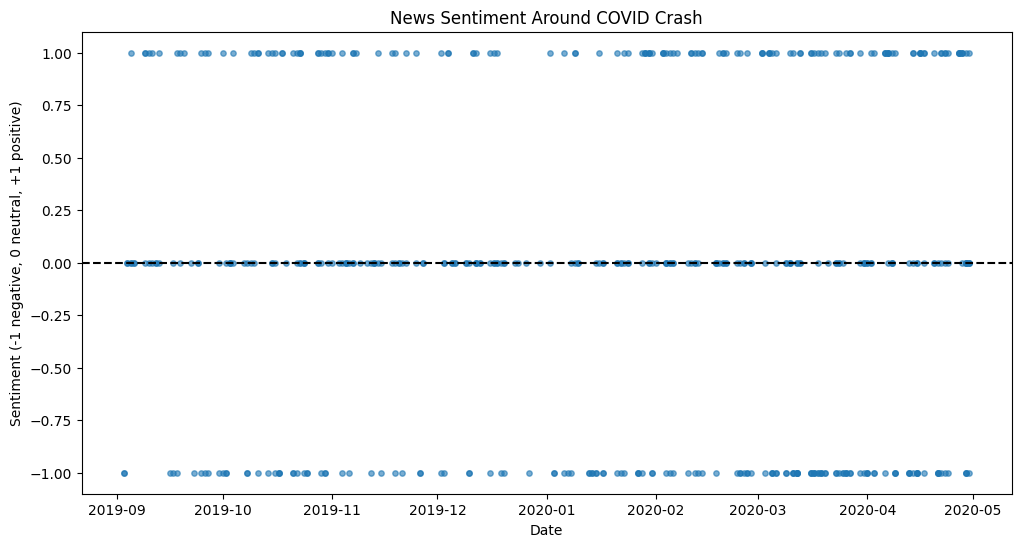

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.scatter(
    df_zoom["date"],
    df_zoom["sentiment_value"],
    alpha=0.6,
    s=15
)

plt.axhline(0, color="black", linestyle="--")

plt.title("News Sentiment Around COVID Crash")
plt.xlabel("Date")
plt.ylabel("Sentiment (-1 negative, 0 neutral, +1 positive)")

plt.show()

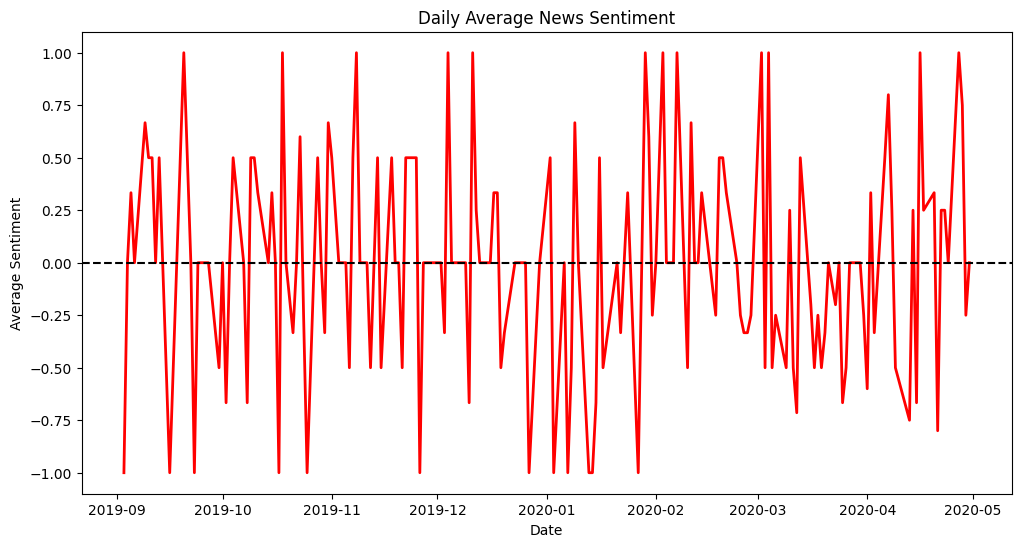

In [54]:
daily_sent = df_zoom.groupby("date")["sentiment_value"].mean().reset_index()

plt.figure(figsize=(12,6))

plt.plot(
    daily_sent["date"],
    daily_sent["sentiment_value"],
    color="red",
    linewidth=2
)

plt.axhline(0, color="black", linestyle="--")

plt.title("Daily Average News Sentiment")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")

plt.show()